# Student FULL name: Huynh Thien Luan Dang

Acknowledgement Statement by students: <br>
	I acknowledge that I have only used GenAI (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions. <br>



### Provide three interesting facts (no more than 4 lines or 70 words) about the diamond industry in Australia, with the link to the source where you got the info.

1. Diamonds were first recorded in Australia in 1851 in New South Wales, with early mining focused on alluvial deposits in areas like Copeton and Bingara. <br>
2. The Argyle mine in Western Australia, discovered in 1979, became the world's largest by volume and supplied over 90% of the world's pink diamonds. <br>
3. Argyle was famous for rare pink and red diamonds and closed in 2020, after which Australia's diamond production dropped sharply. <br>

Source for fact 1: https://australian.museum/learn/minerals/gemstones/diamond/

Source for fact 2: https://www.ga.gov.au/education/minerals-energy/australian-mineral-facts/diamond

Source for fact 3: https://www.brilliyond.com.au/education/diamond-mining/australia

### Conduct Exploratory Data Analysis (EDA) as needed.

In [1]:
# Import essential libraries for all sections
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import inv_boxcox

In [2]:
# Load the CSV file into a DataFrame
diamond = pd.read_csv('data.csv')

In [3]:
# Display the first 5 rows of the dataset
diamond.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.34,Good,Z,SI2,62.2,59,4.35,4.34,2.7,349
1,0.21,Premium,E,SI1,59.8,61,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58,4.2,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58,4.34,4.35,2.75,335


In [4]:
# Display summary info (columns, data types, non-null counts)
diamond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55843 entries, 0 to 55842
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    55843 non-null  object 
 1   cut      55841 non-null  object 
 2   color    55843 non-null  object 
 3   clarity  55842 non-null  object 
 4   depth    55841 non-null  object 
 5   table    55842 non-null  object 
 6   x        55842 non-null  object 
 7   y        55842 non-null  float64
 8   z        55843 non-null  object 
 9   price    55841 non-null  object 
dtypes: float64(1), object(9)
memory usage: 4.3+ MB


In [5]:
# Count the total number of missing values in each column and show them
missing_count = diamond.isnull().sum()
missing_count

carat      0
cut        2
color      0
clarity    1
depth      2
table      1
x          1
y          1
z          0
price      2
dtype: int64

In [6]:
# Display all unique values in the 'carat' column
diamond['carat'].unique()

array(['0.34', '0.21', '0.23', '0.29', '0.31', '0.24', '0.26', '0.22',
       '0.3', '0.2', '0.32', '0.33', '0.25', '0.35', '0.42', '0.28',
       '0.38', '0.7', '0.86', '0.71', '0.78', '0.96', '0.73', '0.8',
       '0.75', '0.74', '0.81', '0.59', '0.9', '0.91', '0.61', '0.77',
       '0.63', '0.76', '0.64', '0.72', '0.79', '0.58', '1.17', '0.6',
       '0.83', '0.54', '0.98', '0.52', '1.01', '0.53', '0.84', '0.51',
       '1.05', '0.55', '0.87', '1', '0.57', '0.82', '1.04', '0.93', '1.2',
       '0.99', '0.43', '0.36', 'na', '0.95', '0.89', '1.02', '0.97',
       '0.56', '0.85', '0.92', '1.27', '0.66', '1.12', '0.68', '1.03',
       '0.62', '1.22', '1.08', '0.88', '0.5', '1.19', ' ', '0.39', '0.65',
       '1.24', '1.5', '0.27', '0.41', '1.13', '1.06', '0.69', '0.4',
       '1.14', '0.94', '1.29', '1.52', '1.16', '1.21', '1.23', '1.09',
       '0.67', '1.11', '1.1', '1.18', '1.15', '1.25', '1.07', '1.28',
       '1.51', '0.37', '1.31', '1.26', '1.39', '1.44', '1.35', '1.3',
       '1.

In [7]:
# Display all unique values in the 'cut' column
diamond['cut'].unique()

array(['Good', 'Premium', 'Very Good', 'Fair', 'Ideal', 'Very Fair', nan,
       'na', ' '], dtype=object)

In [8]:
# Display all unique values in the 'color' column
diamond['color'].unique()

array(['Z', 'E', 'I', 'J', 'H', 'F', 'G', 'D', 'na', 'S', ' ', 'N'],
      dtype=object)

In [9]:
# Display all unique values in the 'clarity' column
diamond['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF', nan, 'na'],
      dtype=object)

In [10]:
# Display all unique values in the 'depth' column
diamond['depth'].unique()

array(['62.2', '59.8', '56.9', '62.4', '63.3', '62.8', '62.3', '61.9',
       '65.1', '59.4', '64', '60.4', '60.2', '60.9', '0.5', '63.4',
       '63.8', '62.7', '61', '58.1', '62.5', '60.5', '60', '60.7', '59.5',
       '58.2', '64.1', '60.8', '61.8', '61.2', '61.1', '65.2', '58.4',
       '63.1', '61.6', '59.3', '62.6', '63', '63.2', '62.1', '61.5',
       '61.4', '62', '62.9', '63.7', '59.2', '59.9', '57.9', '55.1',
       '57.5', '66.3', '61.7', '58.8', '64.5', '65.3', '59.6', '64.4',
       '65.7', '63.6', '61.3', '60.1', '60.3', '58', '64.6', '59.7',
       '57.8', '67.9', '60.6', '57.2', '64.2', '65.8', '67.4', '59',
       '63.5', '67.3', '58.7', nan, '66.4', '68.1', '63.9', '55', '58.6',
       '64.3', '58.5', '65', '56', '58.3', '53.1', 'na', '64.9', '59.1',
       '58.9', '66.7', '57.7', '65.4', '53.3', '53', '67.8', ' ', '66.1',
       '55.8', '67.6', '68.2', '65.5', '67.7', '69.5', '56.6', '56.3',
       '66.9', '66', '67', '57.6', '67.1', '65.6', '64.8', '69.3', '66.2',
 

In [11]:
# # Display all unique values in the 'array' column
diamond['table'].unique()

array(['59', '61', '65', '58', '57', '55', '56', '54', '62', '63', '60',
       '55.3', '69', '53', '64', '56.4', '60.5', '67', '52', '55.8', '66',
       '70', nan, '68', '54.4', ' ', '57.1', '53.6', '54.8', '54.2',
       '54.9', '56.7', '53.9', '57.8', '54.1', '55.1', '51', '58.1',
       '56.9', '56.5', '53.7', '60.7', '56.2', '56.6', '56.1', '56.3',
       '57.2', '57.5', '60.9', '59.8', '62.3', '60.1', '55.9', '50.1',
       '62.2', '54.5', '55.7', '53.4', '54.7', '58.8', '59.4', '62.5',
       '54.3', '60.6', '55.2', '58.6', '49', '50', '54.6', '62.6', '57.7',
       '56.8', '57.9', '60.3', '55.6', '59.5', '57.4', '62.4', '60.4',
       '53.3', '60.2', '60.8', '58.5', '57.6', '43', '59.9', '63.5',
       '57.3', '61.4', '58.3', '55.4', '58.2', '53.5', '59.7', '0',
       '55.5', '58.7', '53.8', '59.1', '53.2', '59.3', '61.1', '51.6',
       '95', '61.2', '59.2', '58.4', '53.1', '52.8', '44', '61.3', '61.9',
       '61.8', '59.6', '61.5', '58.9', '64.3', '62.8', '71', '52.4',
   

In [12]:
# Display all unique values in the 'x' column
diamond['x'].unique()

array(['4.35', '3.89', '4.05', '4.2', '4.34', '3.94', '3.95', '4.07',
       '3.87', '4', '4.25', '3.93', '3.88', '3.79', '4.38', '4.31',
       '4.23', '4.21', '4.26', '3.85', '4.39', '4.44', '3.97', '4.28',
       '3.96', '4.04', '4.01', '3.92', '4.06', '3.83', '4.29', '4.13',
       '4.49', '3.99', '4.19', '4.24', '4.36', '4.33', '4.02', '4.45',
       '3.91', '4.3', '4.43', '4.54', '4.78', '4.15', '4.08', '4.03',
       '4.65', '4.22', '5.7', '6.45', '5.68', '5.81', '5.85', '5.71',
       '6.27', '5.77', '5.97', '5.8', '6', '5.94', '5.87', '5.9', '6.14',
       '5.38', '5.96', '6.16', '5.73', '5.98', '5.72', '6.01', '5.64',
       '5.57', '5.63', '5.65', '6.09', '5.56', '6.11', '6.03', '5.89',
       '5.69', '5.62', '5.88', '5.52', '5.74', '5.53', '5.78', '5.83',
       '5.66', '5.82', '5.79', '5.92', '5.39', '5.33', '6.83', '5.41',
       '5.25', '5.24', '5.67', '5.61', '5.76', '6.05', '5.6', '5.19',
       '5.84', '6.39', '5.34', '5.14', '5.11', '5.54', '6.07', '6.29',
       '6.

In [13]:
# Display all unique values in the 'y' column
diamond['y'].unique()

array([ 4.34,  3.84,  4.07,  4.23,  4.35,  3.96,  3.98,  4.11,  3.78,
        4.05,  4.28,  3.9 ,  4.37,  3.75,  4.42,  4.29,  4.26,  4.27,
        4.3 ,  3.92,  4.43,  4.47,  4.01,  3.94,  3.97,  3.99,  4.03,
        4.06,  4.08,  3.85,  4.31,  4.16,  4.51,  4.5 ,  4.55,  4.02,
        4.24,  4.38,  3.95,  4.48,  3.89,  3.88,  4.33,  4.32,  4.59,
        4.84,  4.22,  4.  ,  4.25,  4.13,  4.09,  4.04,  4.12,  4.67,
        5.72,  6.33,  5.67,  5.73,  5.85,  5.9 ,  5.76,  5.95,  5.78,
        5.93,  5.75,  5.96,  5.79,  5.87,  5.8 ,  5.81,  6.11,  5.43,
        6.  ,  5.84,  6.12,  5.82,  5.74,  5.94,  6.07,  5.69,  5.83,
        5.61,  5.53,  5.58,  5.59,  5.97,  6.09,  5.99,  5.86,  5.68,
        5.65,  5.55,  5.77,  5.91,  5.56,  5.89,  5.92,  6.03,  5.44,
        5.37,  5.88,  6.9 ,  5.62,  5.27,  5.26,  5.7 ,  5.64,  5.63,
        5.71,  5.51,  5.22,  6.36,  5.54,  5.66,  6.2 ,  5.18,  5.15,
        6.1 ,  6.21,  6.22,  6.45,  6.01,  5.3 ,  5.41,  5.52,  6.27,
        6.05,  6.06,

In [14]:
# Display all unique values in the 'z' column
diamond['z'].unique()

array(['2.7', '2.31', '2.63', '2.75', '2.48', '2.47', '2.53', '2.49',
       '2.39', '2.73', '2.46', '2.33', '2.71', '2.27', '2.68', '2.66',
       '2.41', '2.62', '2.59', '2.67', '2.4', '2.42', '2.44', '2.37',
       '2.52', '2.78', '2.76', '2.61', '2.65', '2.79', '2.54', '2.64',
       '2.45', '2.72', '2.69', '2.96', '2.58', '2.51', '2.56', '2.55',
       '2.87', '3.57', '3.52', '3.5', '3.56', '3.72', '3.38', '3.4',
       '4.07', '3.66', '3.65', '3.58', '3.59', '3.63', '3.69', '3.61',
       '3.6', '3.35', '3.67', '3.62', '3.87', '3.68', '3.49', '3.47',
       '3.46', '3.7', '3.32', '3.93', '3.95', '3.64', '3.53', '3.37',
       '3.43', '3.51', '3.54', '3.48', '3.55', '3.33', '3.3', '4.13',
       '3.79', '3.24', '3.23', '4.08', '3.19', '3.94', '3.08', '3.31',
       '3.21', '3.75', '3.18', '3.41', '4.03', '4.09', '3.22', '4.18',
       '3.76', '3.83', '3.17', '3.44', '3.74', '3.8', '3.39', '3.88', '4',
       '3.98', '3.85', '3.96', '3.16', '3.78', '3.84', '4.33', '4.01',
       '3

In [15]:
# Display all unique values in the 'price' column
diamond['price'].unique()

array(['349', '326', '327', ..., '387', '278', '274'],
      shape=(12379,), dtype=object)

In [16]:
# Reload the CSV, treating empty strings, spaces, NaN, null, NULL, None, na, and 0 as missing values
diamond = pd.read_csv('data.csv', na_values=['', ' ', 'NaN', 'null', 'NULL', 'None', 'na', 0])

In [17]:
# Display summary info (columns, data types, non-null counts)
diamond.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55843 entries, 0 to 55842
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    55840 non-null  float64
 1   cut      55839 non-null  object 
 2   color    55838 non-null  object 
 3   clarity  55841 non-null  object 
 4   depth    55835 non-null  float64
 5   table    55839 non-null  float64
 6   x        55830 non-null  float64
 7   y        55834 non-null  float64
 8   z        55819 non-null  float64
 9   price    55838 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.3+ MB


In [18]:
# Convert the data type of numeric columns from object to float64 for analysis
diamond['carat'] = pd.to_numeric(diamond['carat'], errors='coerce')
diamond['depth'] = pd.to_numeric(diamond['depth'], errors='coerce')
diamond['table'] = pd.to_numeric(diamond['table'], errors='coerce')
diamond['x'] = pd.to_numeric(diamond['x'], errors='coerce')
diamond['z'] = pd.to_numeric(diamond['z'], errors='coerce')
diamond['price'] = pd.to_numeric(diamond['price'], errors='coerce')

In [19]:
# Display the count of missing values per column
diamond.isnull().sum()

carat       3
cut         4
color       5
clarity     2
depth       8
table       4
x          13
y           9
z          24
price       5
dtype: int64

In [20]:
# Count missing values per row:
missing_values_per_row = diamond.isnull().sum(axis=1)

# Filter and display only rows that contain at least one missing value
rows_with_nulls = diamond[missing_values_per_row > 0]
print("Rows with at least one missing value:\n", rows_with_nulls)

Rows with at least one missing value:
        carat        cut color clarity  depth  table     x     y     z    price
307     0.90  Very Good     I     SI2   61.3   56.0   NaN  6.23  3.80   2800.0
319     0.71    Premium     F     NaN   62.1   58.0  5.70  5.67  3.53   2801.0
325     0.87  Very Good     G     SI2   59.9    NaN  6.19  6.23  3.72   2802.0
327     0.72    Premium     E     VS2   63.0   55.0  5.79  5.61  3.59      NaN
355     0.73        NaN     E     SI2   61.8   58.0  5.77  5.81  3.58   2805.0
360     0.82       Good     G     VS2    NaN   57.0  5.92  5.89  3.78   2805.0
364     0.71  Very Good     F     VS1   62.2   58.0  5.66   NaN  3.54   2807.0
407     0.31  Very Good     F     SI1    NaN   58.0  4.32  4.35  2.68    555.0
411     0.34      Ideal     I     VS1   62.0   56.0  4.50  4.53  2.80      NaN
412     0.30        NaN     G     VS1   62.3   56.0  4.29  4.31  2.68    555.0
426      NaN    Premium     G     SI2   59.8   58.0  6.30  6.29  3.77   2813.0
432     0.55 

In [21]:
# Drop rows where 'cut', 'color', or 'clarity' have missing values
diamond.dropna(subset=['cut', 'color', 'clarity'], inplace=True)

# Double check by showing rows with at least one null value again:
missing_values_per_row = diamond.isnull().sum(axis=1)
rows_with_nulls = diamond[missing_values_per_row > 0]
print("Rows with at least one missing value:\n", rows_with_nulls)

Rows with at least one missing value:
        carat        cut color clarity  depth  table     x     y     z    price
307     0.90  Very Good     I     SI2   61.3   56.0   NaN  6.23  3.80   2800.0
325     0.87  Very Good     G     SI2   59.9    NaN  6.19  6.23  3.72   2802.0
327     0.72    Premium     E     VS2   63.0   55.0  5.79  5.61  3.59      NaN
360     0.82       Good     G     VS2    NaN   57.0  5.92  5.89  3.78   2805.0
364     0.71  Very Good     F     VS1   62.2   58.0  5.66   NaN  3.54   2807.0
407     0.31  Very Good     F     SI1    NaN   58.0  4.32  4.35  2.68    555.0
411     0.34      Ideal     I     VS1   62.0   56.0  4.50  4.53  2.80      NaN
426      NaN    Premium     G     SI2   59.8   58.0  6.30  6.29  3.77   2813.0
432     0.55  Very Good     D    VVS1   61.5   56.0  5.23  5.27   NaN   2815.0
509     0.70      Ideal     D     SI1   61.4   54.0   NaN  5.71  3.52   2822.0
559     0.72    Premium     E     SI1    NaN   58.0  5.73  5.76  3.57   2831.0
680     0.70 

In [22]:
# Fill missing values in 'carat' with the column's median
diamond['carat'] = diamond['carat'].fillna(diamond['carat'].median())

In [23]:
# Fill missing values in 'depth' with the column's median
diamond['depth'] = diamond['depth'].fillna(diamond['depth'].median())

In [24]:
# Fill missing values in 'table' with the column's median
diamond['table'] = diamond['table'].fillna(diamond['table'].median())

In [25]:
# Fill missing values in 'x' with the column's median
diamond['x'] = diamond['x'].fillna(diamond['x'].median())

In [26]:
# Fill missing values in 'y' with the column's median
diamond['y'] = diamond['y'].fillna(diamond['y'].median())

In [27]:
# Fill missing values in 'z' with the column's median
diamond['z'] = diamond['z'].fillna(diamond['z'].median())

In [28]:
# Fill missing values in 'price' with the column's median
diamond['price'] = diamond['price'].fillna(diamond['price'].median())

In [29]:
# Count and display remaining missing values per column to verify
missing_values_per_column = diamond.isnull().sum()
print("Missing values per column:\n", missing_values_per_column)

Missing values per column:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64


In [30]:
# Returns the total number of duplicate rows
duplicate_count = diamond.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 147


In [31]:
# Filters the dataframe to show only the duplicate records
duplicate_rows = diamond[diamond.duplicated(keep=False)] 
print(duplicate_rows)

       carat    cut color clarity  depth  table     x     y     z   price
11      0.23  Ideal     J     VS1   62.8   56.0  3.93  3.90  2.46   340.0
1004    0.79  Ideal     G     SI1   62.3   57.0  5.90  5.85  3.66  2898.0
1005    0.79  Ideal     G     SI1   62.3   57.0  5.90  5.85  3.66  2898.0
1006    0.79  Ideal     G     SI1   62.3   57.0  5.90  5.85  3.66  2898.0
1007    0.79  Ideal     G     SI1   62.3   57.0  5.90  5.85  3.66  2898.0
...      ...    ...   ...     ...    ...    ...   ...   ...   ...     ...
50086   0.51  Ideal     F    VVS2   61.2   56.0  5.19  5.17  3.17  2203.0
50087   0.51  Ideal     F    VVS2   61.2   56.0  5.19  5.17  3.17  2203.0
52868   0.50   Fair     E     VS2   79.0   73.0  5.21  5.18  4.09  2579.0
52869   0.50   Fair     E     VS2   79.0   73.0  5.21  5.18  4.09  2579.0
55842   0.23  Ideal     J     VS1   62.8   56.0  3.93  3.90  2.46   340.0

[291 rows x 10 columns]


In [32]:
# Removes duplicates
diamond.drop_duplicates(inplace=True)

In [33]:
# Check duplicates again
duplicate_rows = diamond[diamond.duplicated(keep=False)] 
print(duplicate_rows)

Empty DataFrame
Columns: [carat, cut, color, clarity, depth, table, x, y, z, price]
Index: []


In [34]:
# Save the DataFrame with missing values treated to a new CSV file
diamond.to_csv('data_cleaned_missingvalues_duplicates.csv', index=False)

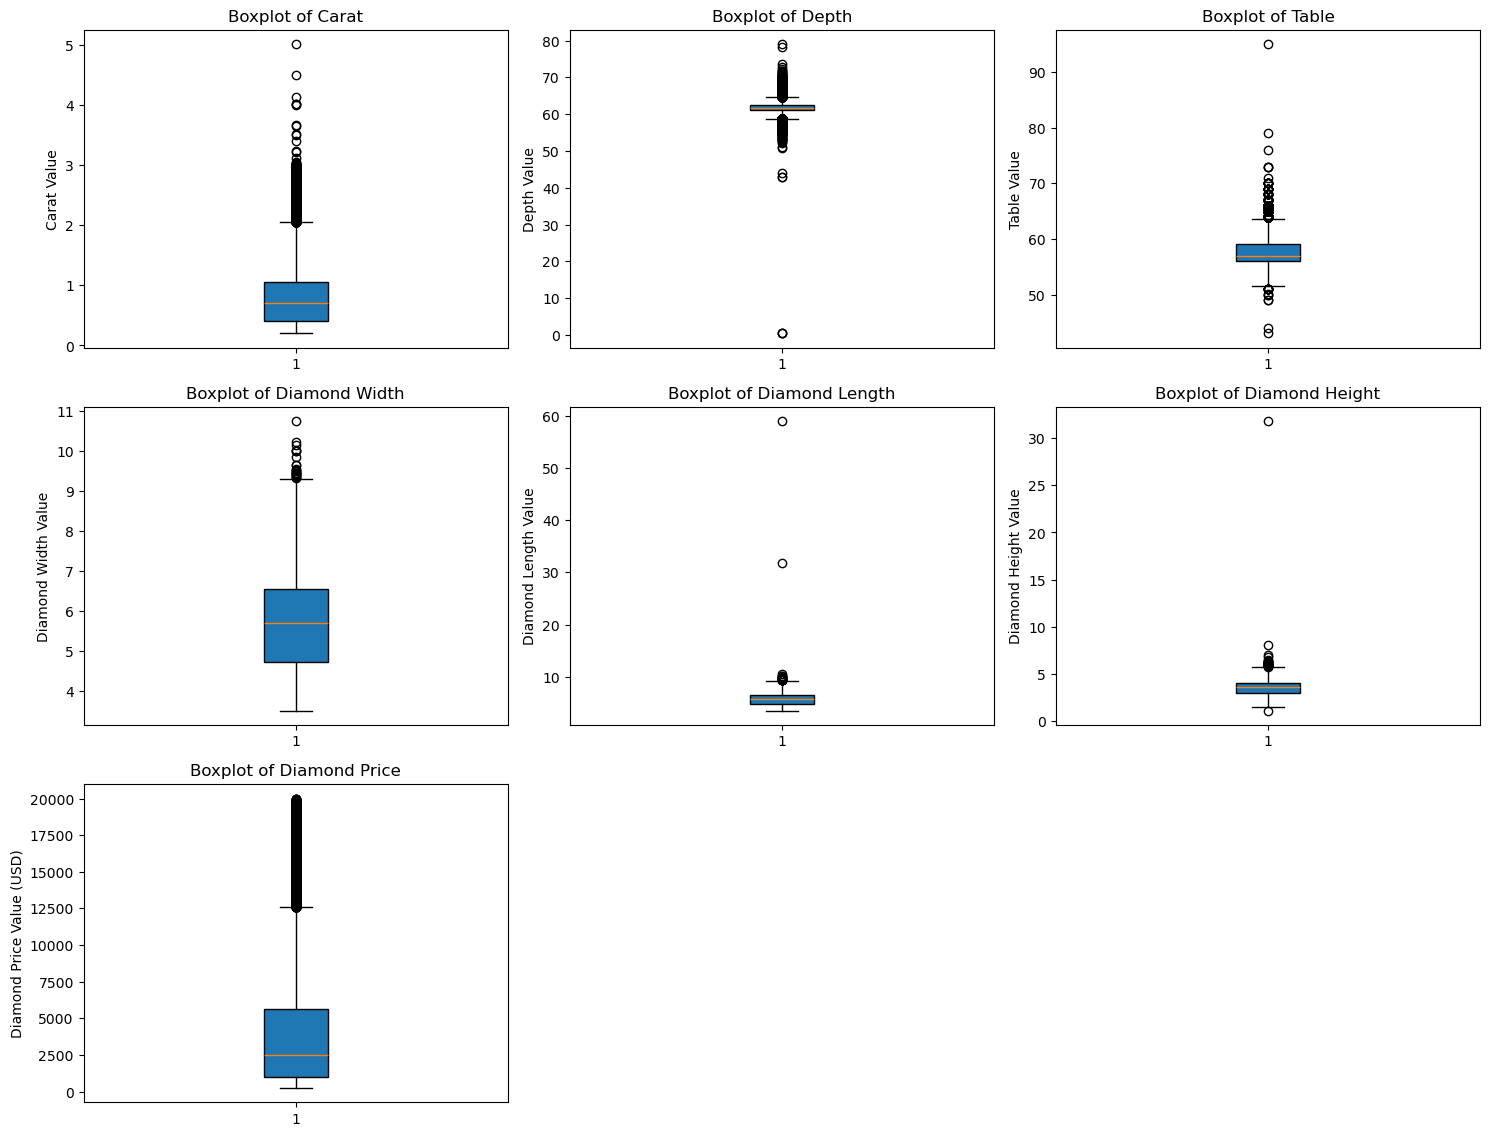

,carat,depth,table,x,y,z,price
count,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000
mean,0.822356,61.690330,57.519969,5.744512,5.747109,3.545239,4130.223094
std,0.507898,1.592895,2.336868,1.141849,1.161741,0.715684,4200.321530
min,0.200000,0.400000,43.000000,3.500000,3.500000,1.070000,252.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,966.000000
50%,0.710000,61.800000,57.000000,5.700000,5.710000,3.530000,2515.000000
75%,1.060000,62.500000,59.000000,6.550000,6.550000,4.040000,5607.000000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,19996.000000


In [35]:
# Create a figure with specified size for displaying multiple boxplots
plt.figure(figsize=(15, 15))

# Carat boxplot
plt.subplot(4, 3, 1)
plt.boxplot(diamond['carat'],patch_artist=True)
plt.title('Boxplot of Carat')
plt.ylabel('Carat Value')

# Depth boxplot
plt.subplot(4, 3, 2)
plt.boxplot(diamond['depth'], patch_artist=True)
plt.title('Boxplot of Depth')
plt.ylabel('Depth Value')

# Table boxplot
plt.subplot(4, 3, 3)
plt.boxplot(diamond['table'], patch_artist=True)
plt.title('Boxplot of Table')
plt.ylabel('Table Value')

# Width boxplot
plt.subplot(4, 3, 4)
plt.boxplot(diamond['x'], patch_artist=True)
plt.title('Boxplot of Diamond Width')
plt.ylabel('Diamond Width Value')

# Length boxplot
plt.subplot(4, 3, 5)
plt.boxplot(diamond['y'], patch_artist=True)
plt.title('Boxplot of Diamond Length')
plt.ylabel('Diamond Length Value')

# Height boxplot
plt.subplot(4, 3, 6)
plt.boxplot(diamond['z'], patch_artist=True)
plt.title('Boxplot of Diamond Height')
plt.ylabel('Diamond Height Value')

# Price boxplot
plt.subplot(4, 3, 7)
plt.boxplot(diamond['price'], patch_artist=True)
plt.title('Boxplot of Diamond Price')
plt.ylabel('Diamond Price Value (USD)')

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Display all the boxplots
plt.show()

# Display summary statistics for all numeric columns
diamond.describe()

In [36]:
# Calculate the first quantile, the third quantile, and the interquartile range of carat
Q1_carat = diamond['carat'].quantile(0.25)
Q3_carat = diamond['carat'].quantile(0.75)
IQR_carat = Q3_carat - Q1_carat

# Calculate the upper and lower bound
lower_carat = Q1_carat - 1.5 * IQR_carat
upper_carat= Q3_carat + 1.5 * IQR_carat

# Calculate the median of carat
median_carat = diamond['carat'].median()

# Replace outliers (values below the lower bound and above the upper bound) with the median 
diamond.loc[(diamond['carat'] < lower_carat) | (diamond['carat'] > upper_carat), 'carat'] = median_carat

In [37]:
# Calculate the first quantile, the third quantile, and the interquartile range of depth
Q1_depth = diamond['depth'].quantile(0.25)
Q3_depth = diamond['depth'].quantile(0.75)
IQR_depth = Q3_depth - Q1_depth

# Calculate the upper and lower bound
lower_depth = Q1_depth - 1.5 * IQR_depth
upper_depth= Q3_depth + 1.5 * IQR_depth

# Calculate the median of depth
median_depth = diamond['depth'].median()

# Replace outliers (values below the lower bound and above the upper bound) with the median
diamond.loc[(diamond['depth'] < lower_depth) | (diamond['depth'] > upper_depth), 'depth'] = median_depth

In [38]:
# Calculate the first quantile, the third quantile, and the interquartile range of table
Q1_table = diamond['table'].quantile(0.25)
Q3_table = diamond['table'].quantile(0.75)
IQR_table = Q3_table - Q1_table

# Calculate the upper and lower bound
lower_table = Q1_table - 1.5 * IQR_table
upper_table= Q3_table + 1.5 * IQR_table

# Calculate the median of table
median_table = diamond['table'].median()

# Replace outliers (values below the lower bound and above the upper bound) with the median
diamond.loc[(diamond['table'] < lower_table) | (diamond['table'] > upper_table), 'table'] = median_table

In [39]:
# Calculate the first quantile, the third quantile, and the interquartile range of width
Q1_x = diamond['x'].quantile(0.25)
Q3_x = diamond['x'].quantile(0.75)
IQR_x = Q3_x - Q1_x

# Calculate the upper and lower bound
lower_x = Q1_x - 1.5 * IQR_x
upper_x= Q3_x + 1.5 * IQR_x

# Calculate the median of width
median_x = diamond['x'].median()

# Replace outliers (values below the lower bound and above the upper bound) with the median
diamond.loc[(diamond['x'] < lower_x) | (diamond['x'] > upper_x), 'x'] = median_x

In [40]:
# Calculate the first quantile, the third quantile, and the interquartile range of length
Q1_y = diamond['y'].quantile(0.25)
Q3_y = diamond['y'].quantile(0.75)
IQR_y = Q3_y - Q1_y

# Calculate the upper and lower bound
lower_y = Q1_y - 1.5 * IQR_y
upper_y= Q3_y + 1.5 * IQR_y

# Calculate the median of length
median_y = diamond['y'].median()

# Replace outliers (values below the lower bound and above the upper bound) with the median
diamond.loc[(diamond['y'] < lower_y) | (diamond['y'] > upper_y), 'y'] = median_y

In [41]:
# Calculate the first quantile, the third quantile, and the interquartile range of height
Q1_z = diamond['z'].quantile(0.25)
Q3_z = diamond['z'].quantile(0.75)
IQR_z = Q3_z - Q1_z

# Calculate the upper and lower bound
lower_z = Q1_z - 1.5 * IQR_z
upper_z= Q3_z + 1.5 * IQR_z

# Calculate the median of length
median_z = diamond['z'].median()

diamond.loc[(diamond['z'] < lower_z) | (diamond['z'] > upper_z), 'z'] = median_z

In [42]:
Q1_price = diamond['price'].quantile(0.25)
Q3_price = diamond['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

median_price = diamond['price'].median()

diamond.loc[(diamond['price'] < lower_price) | (diamond['price'] > upper_price), 'price'] = median_price

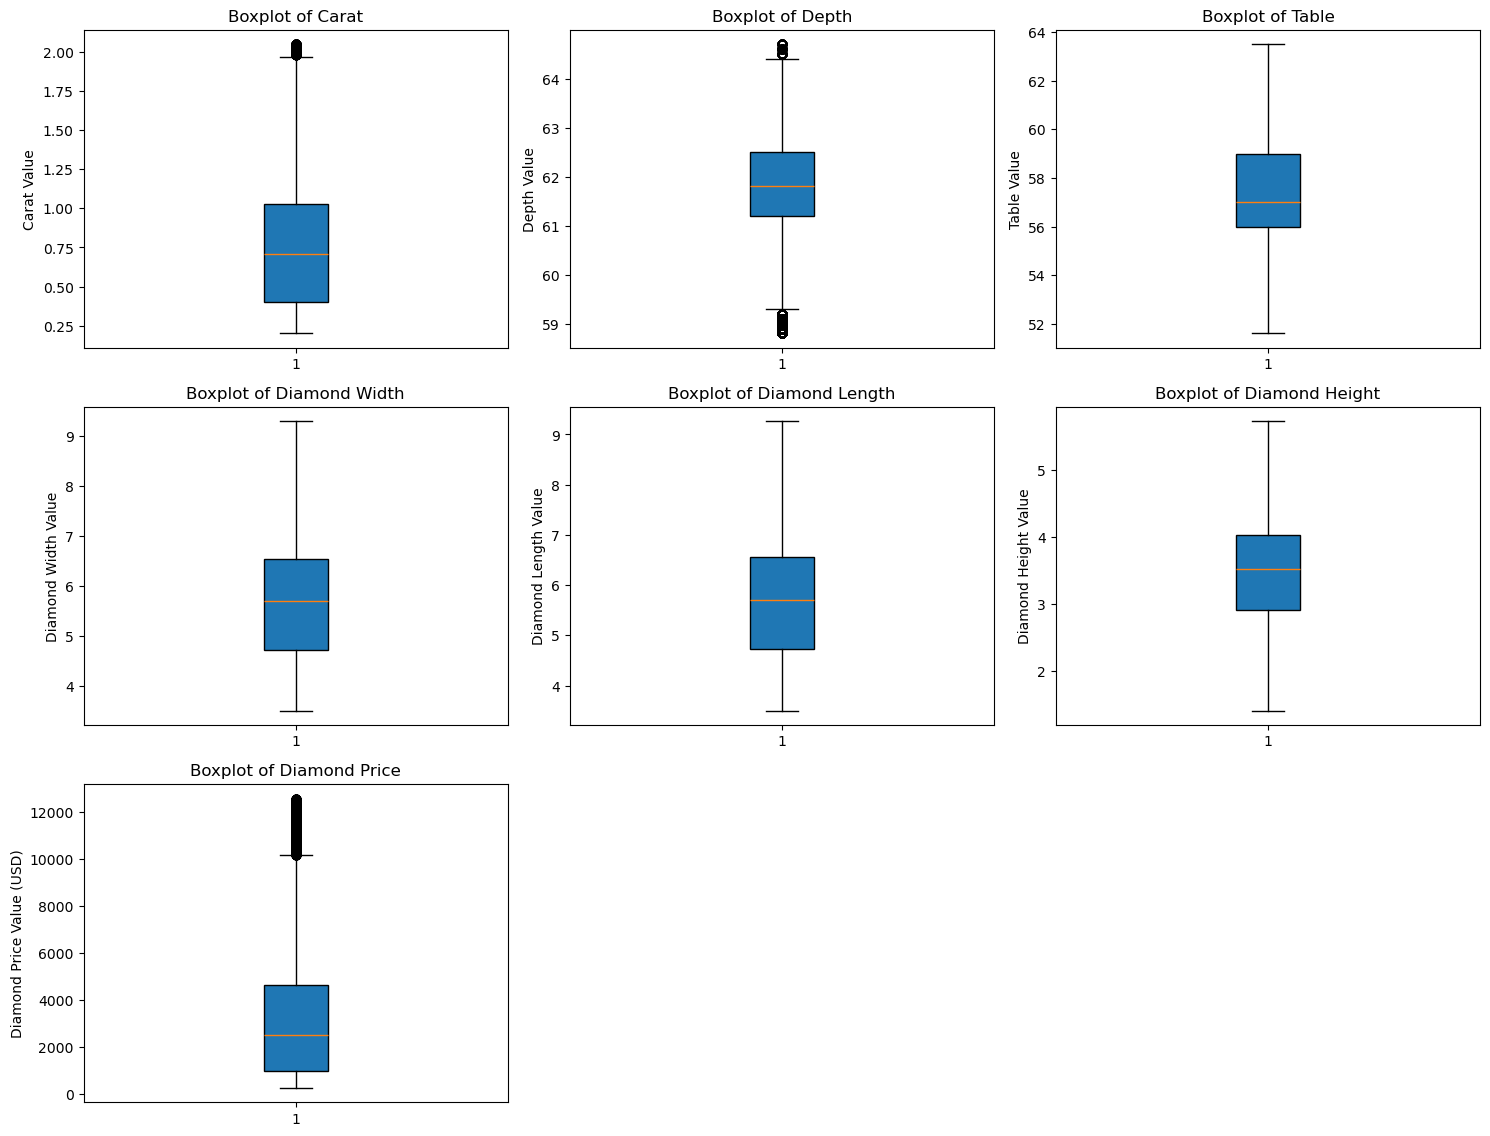

,carat,depth,table,x,y,z,price
count,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000,55685.000000
mean,0.775158,61.777315,57.382177,5.742873,5.744275,3.543593,3259.175308
std,0.430922,1.099662,2.092826,1.139038,1.131916,0.703252,2850.690284
min,0.200000,58.800000,51.600000,3.500000,3.500000,1.410000,252.000000
25%,0.400000,61.200000,56.000000,4.710000,4.720000,2.910000,966.000000
50%,0.710000,61.800000,57.000000,5.700000,5.710000,3.530000,2515.000000
75%,1.030000,62.500000,59.000000,6.550000,6.550000,4.040000,4640.000000
max,2.050000,64.700000,63.500000,9.300000,9.260000,5.730000,12566.000000


In [43]:
# Create a figure with specified size for displaying multiple boxplots
plt.figure(figsize=(15, 15))

# Carat boxplot
plt.subplot(4, 3, 1)
plt.boxplot(diamond['carat'],patch_artist=True)
plt.title('Boxplot of Carat')
plt.ylabel('Carat Value')

# Depth boxplot
plt.subplot(4, 3, 2)
plt.boxplot(diamond['depth'], patch_artist=True)
plt.title('Boxplot of Depth')
plt.ylabel('Depth Value')

# Table boxplot
plt.subplot(4, 3, 3)
plt.boxplot(diamond['table'], patch_artist=True)
plt.title('Boxplot of Table')
plt.ylabel('Table Value')

# Width boxplot
plt.subplot(4, 3, 4)
plt.boxplot(diamond['x'], patch_artist=True)
plt.title('Boxplot of Diamond Width')
plt.ylabel('Diamond Width Value')

# Length boxplot
plt.subplot(4, 3, 5)
plt.boxplot(diamond['y'], patch_artist=True)
plt.title('Boxplot of Diamond Length')
plt.ylabel('Diamond Length Value')

# Height boxplot
plt.subplot(4, 3, 6)
plt.boxplot(diamond['z'], patch_artist=True)
plt.title('Boxplot of Diamond Height')
plt.ylabel('Diamond Height Value')

# Price boxplot
plt.subplot(4, 3, 7)
plt.boxplot(diamond['price'], patch_artist=True)
plt.title('Boxplot of Diamond Price')
plt.ylabel('Diamond Price Value (USD)')

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Display all the boxplots
plt.show()

# Display summary statistics for all numeric columns
diamond.describe()

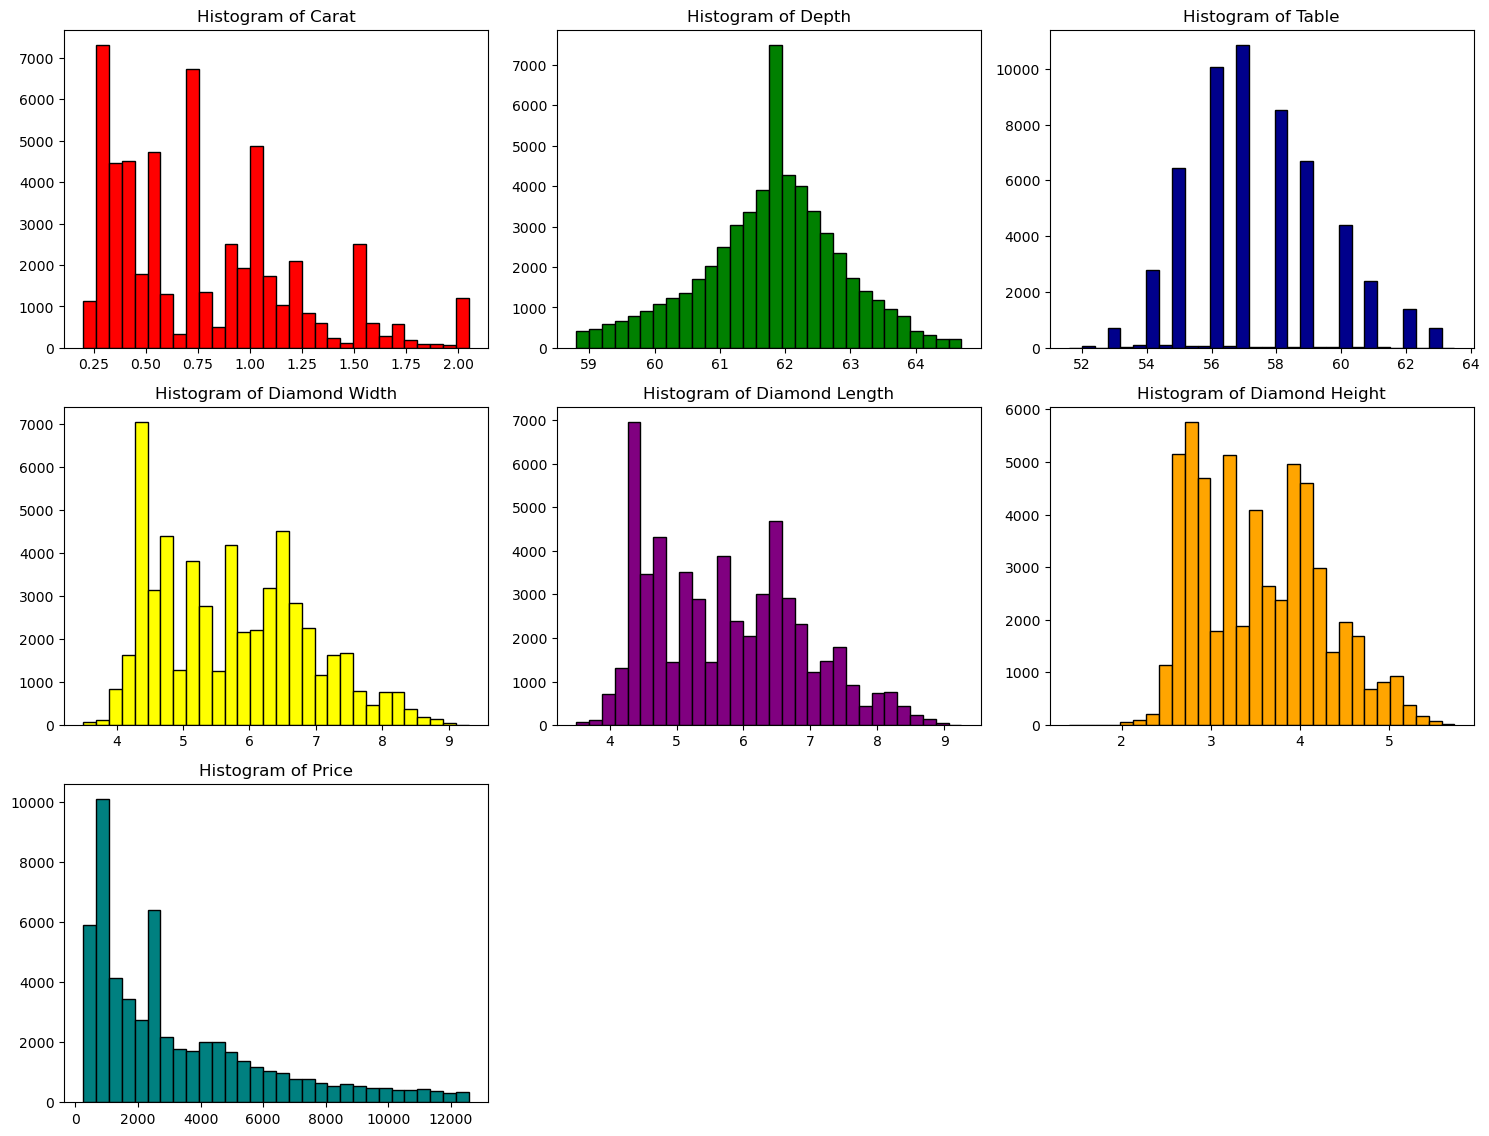

In [44]:
# Create a figure with specified size for displaying multiple histograms
plt.figure(figsize=(15, 15))

# Carat histogram
plt.subplot(4,3,1)
plt.hist(diamond['carat'], bins=30, color='red', edgecolor='black')
plt.title('Histogram of Carat')

# Depth histogram
plt.subplot(4,3,2)
plt.hist(diamond['depth'], bins=30, color='green', edgecolor='black')
plt.title('Histogram of Depth')

# Table histogram
plt.subplot(4,3,3)
plt.hist(diamond['table'], bins=30, color='darkblue', edgecolor='black')
plt.title('Histogram of Table')

# Width histogram
plt.subplot(4,3,4)
plt.hist(diamond['x'], bins=30, color='yellow', edgecolor='black')
plt.title('Histogram of Diamond Width')

# Length histogram
plt.subplot(4,3,5)
plt.hist(diamond['y'], bins=30, color='purple', edgecolor='black')
plt.title('Histogram of Diamond Length')

# Height histogram
plt.subplot(4,3,6)
plt.hist(diamond['z'], bins=30, color='orange', edgecolor='black')
plt.title('Histogram of Diamond Height')

# Price histogram
plt.subplot(4,3,7)
plt.hist(diamond['price'], bins=30, color='teal', edgecolor='black')
plt.title('Histogram of Price')

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Display all the histograms
plt.show()

In [45]:
# Calculate and show skewness of numeric columns
skewness = diamond.skew(numeric_only=True)

print("Skewness of each numerical variable:")
print(skewness)

Skewness of each numerical variable:
carat    0.870553
depth   -0.245794
table    0.379194
x        0.400662
y        0.395354
z        0.378238
price    1.292520
dtype: float64


In [46]:
# Fix skewness for columns with skewness values under -0.5 and above 0.5
# carat, price

In [47]:
# carat

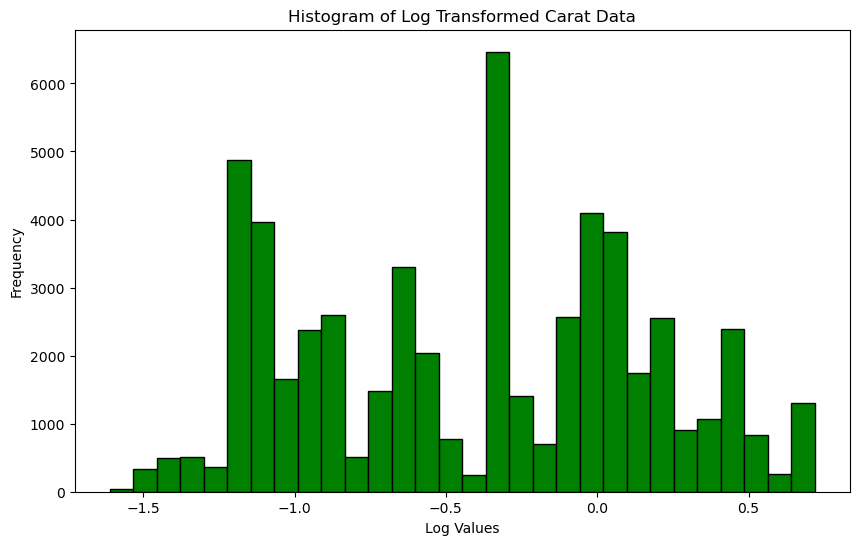

In [48]:
# Apply log transformation to fix skewness
diamond['carat_log'] = np.log(diamond['carat'])

# Display histogram after log transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['carat_log'], bins=30, color='green', edgecolor='black')
plt.title('Histogram of Log Transformed Carat Data')
plt.xlabel('Log Values')
plt.ylabel('Frequency')
plt.show()

In [49]:
# Calculate and show skewness after log transformation
skewness_after_log_carat = diamond['carat_log'].skew()
skewness_after_log_carat

np.float64(0.021610172335771692)

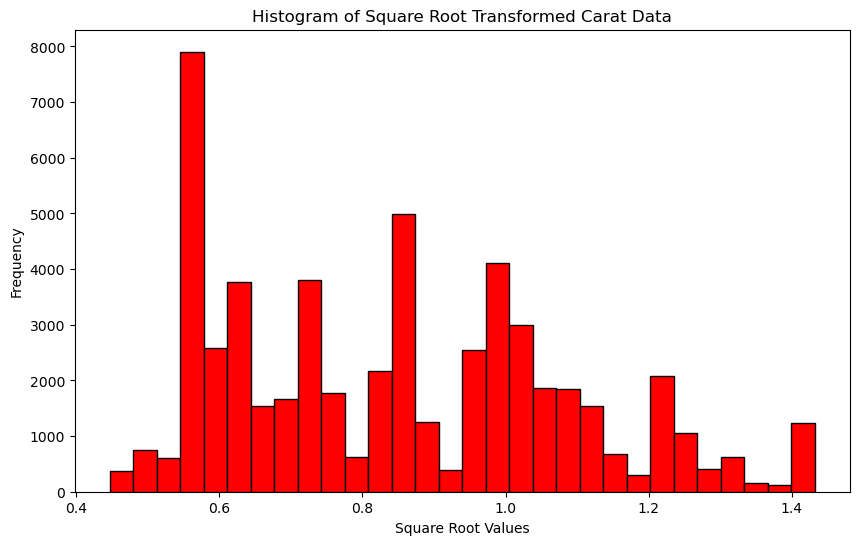

In [50]:
# Apply square root transformation to fix skewness
diamond['carat_sqrt'] = np.sqrt(diamond['carat'])

# Display histogram after square root transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['carat_sqrt'], bins=30, color='red', edgecolor='black')
plt.title('Histogram of Square Root Transformed Carat Data')
plt.xlabel('Square Root Values')
plt.ylabel('Frequency')
plt.show()

In [51]:
# Calculate and show skewness after square root transformation
skewness_after_sqrt_carat = diamond['carat_sqrt'].skew()
skewness_after_sqrt_carat

np.float64(0.4205283326895187)

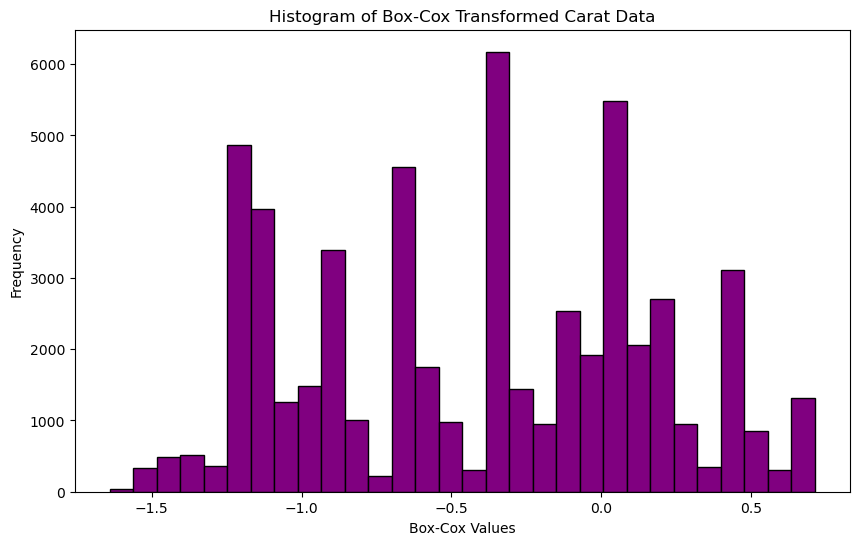

In [52]:
# Apply Box-Cox transformation to fix skewness
diamond['carat_boxcox'], _ = stats.boxcox(diamond['carat'])

# Display histogram after Box-Cox transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['carat_boxcox'], bins=30, color='purple', edgecolor='black')
plt.title('Histogram of Box-Cox Transformed Carat Data')
plt.xlabel('Box-Cox Values')
plt.ylabel('Frequency')
plt.show()

In [53]:
# Calculate and show skewness after box-cox transformation
skewness_after_boxcox_carat = diamond['carat_boxcox'].skew()
skewness_after_boxcox_carat

np.float64(0.004747841200850401)

In [54]:
# Box cox transformation gives the best results for carat

In [55]:
# price

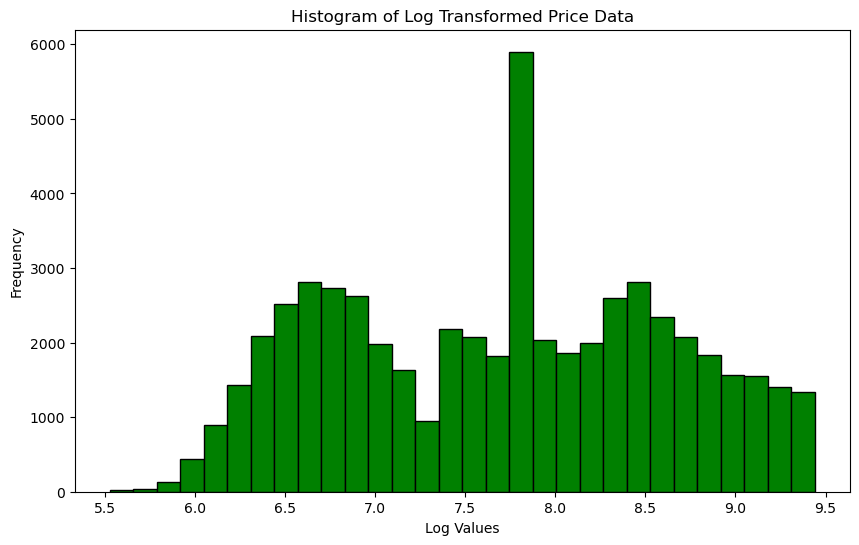

In [56]:
# Apply log transformation to fix skewness
diamond['price_log'] = np.log(diamond['price'])

# Display histogram after log transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['price_log'], bins=30, color='green', edgecolor='black')
plt.title('Histogram of Log Transformed Price Data')
plt.xlabel('Log Values')
plt.ylabel('Frequency')
plt.show()

In [57]:
# Calculate and show skewness after log transformation
skewness_after_log_price = diamond['price_log'].skew()
skewness_after_log_price

np.float64(-0.008970628135220636)

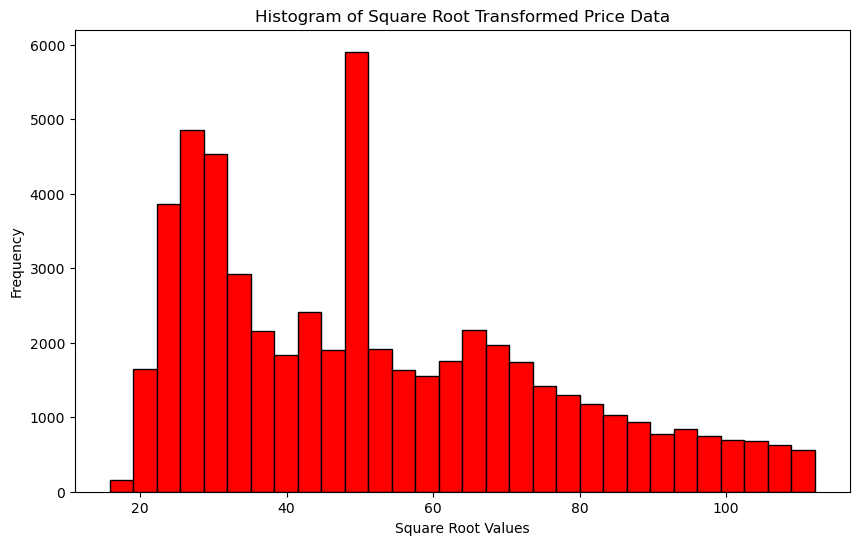

In [58]:
# Apply square root transformation to fix skewness
diamond['price_sqrt'] = np.sqrt(diamond['price'])

# Display histogram after square root transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['price_sqrt'], bins=30, color='red', edgecolor='black')
plt.title('Histogram of Square Root Transformed Price Data')
plt.xlabel('Square Root Values')
plt.ylabel('Frequency')
plt.show()

In [59]:
# Calculate skewness after square root transformation
skewness_after_sqrt_price = diamond['price_sqrt'].skew()
skewness_after_sqrt_price

np.float64(0.6441706696640567)

In [60]:
# Apply Box-Cox transformation to fix skewness, save its lambda for later to inverse transform so that we can report the evaluation metrics of model training in the correct scale
diamond['price_boxcox'], lambda_price = stats.boxcox(diamond['price'])
print(f"Lambda for price: {lambda_price}")

Lambda for price: 0.0056145562827751416


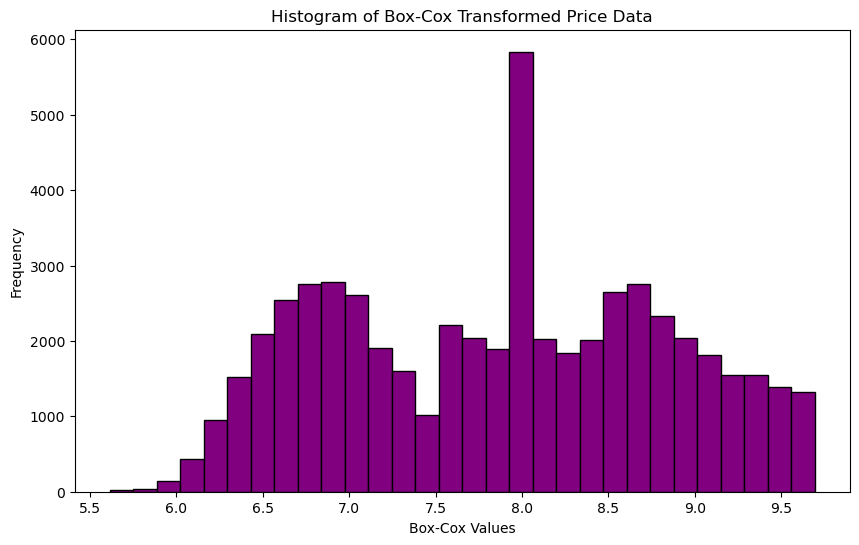

In [61]:
# Display histogram after Box-Cox transformation
plt.figure(figsize=(10, 6))
plt.hist(diamond['price_boxcox'], bins=30, color='purple', edgecolor='black')
plt.title('Histogram of Box-Cox Transformed Price Data')
plt.xlabel('Box-Cox Values')
plt.ylabel('Frequency')
plt.show()

In [62]:
# Calculate and show skewness after box-cox transformation
skewness_after_boxcox_price = diamond['price_boxcox'].skew()
skewness_after_boxcox_price

np.float64(-0.0018263574275930344)

In [63]:
# Boxcox transformation gives the best results for price

In [64]:
# Save the DataFrame with missing values, outliers, and skewness treated to a new CSV file
diamond.to_csv('data_cleaned_full.csv', index=False)

### Develop and visualise four descriptive questions that would drive insightful values for Aurora Gems.

#### Visualisation 1: How does the carat weight of a diamond affect its price?
Understanding this relationship helps Aurora Gems price their diamonds accurately based on weight and helps predict the value of new inventory.

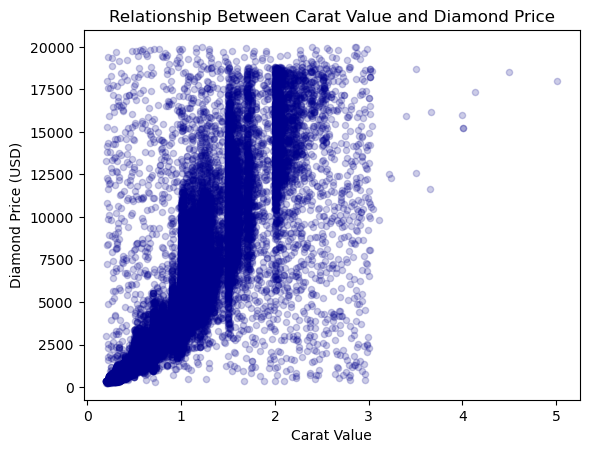

In [65]:
# Load the cleaned diamond dataset into a DataFrame
diamond_visualisation = pd.read_csv('data_cleaned_missingvalues_duplicates.csv')

# Plot carat against price as a scatter, with transparency to show point density
diamond_visualisation.plot.scatter(x='carat', y='price', c='DarkBlue', alpha=0.2)

# Label the x-axis
plt.xlabel('Carat Value')

# Label the y-axis
plt.ylabel('Diamond Price (USD)')

# Add a title to the plot
plt.title('Relationship Between Carat Value and Diamond Price')

# Render and display the plot
plt.show()

##### Insights and Recommendations

The scatter plot shows a clear positive relationship between carat weight and price, with heavier diamonds commanding higher prices on average. However, the relationship is weak as a standalone predictor: at almost every carat level the price spread is very wide, with one-carat stones ranging from a few hundred dollars to near the top of the scale. This indicates that other attributes such as cut, clarity, and colour are doing substantial work in setting value. The vertical banding at 1.0, 1.5, and 2.0 carats reflects the market tendency to cut stones to land just above psychologically important weight thresholds, where price jumps disproportionately. Prices also appear to flatten near a 20,000 USD ceiling, and inventory above 3 carats is sparse but priced consistently at a premium.

Management should therefore avoid pricing on carat weight alone and instead use a multivariate model incorporating cut, clarity, and colour to explain the variance left unaddressed here and reduce mispricing. The wide price dispersion at common 1.0 and 2.0 carat weights should be reviewed to confirm it stems from genuine quality differences rather than inconsistent pricing, and the threshold effects present a sourcing opportunity, since stones just below a round weight can be acquired more cheaply while appearing similar to buyers. Finally, the 20,000 USD ceiling should be validated before use in any valuation work, as it may reflect data capping rather than true market prices.

#### Visualisation 2: What is the average price of diamonds across different cut types?
This helps Aurora Gems understand the price that customers pay for better cut qualities. It can guide purchasing decisions like if one type of cuts yield significantly higher prices, Aurora Gem might want to stock more of it.

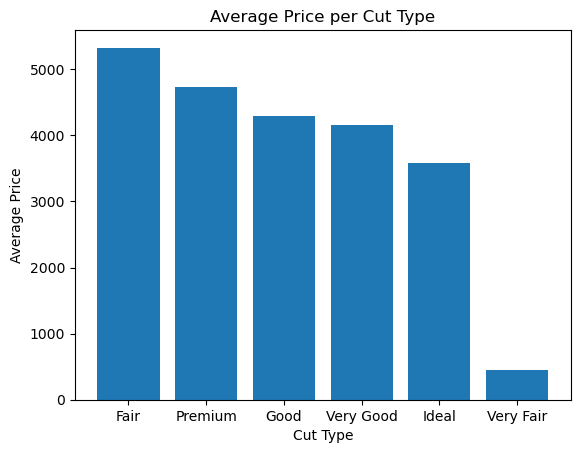

In [66]:
# Load the cleaned diamond dataset into a DataFrame
diamond_visualisation = pd.read_csv('data_cleaned_missingvalues_duplicates.csv')

# Calculate the average price for each cut type, sorted from highest to lowest
avg_price = diamond_visualisation.groupby('cut')['price'].mean().sort_values(ascending=False)

# Plot the average price per cut type as a bar chart
plt.bar(x=avg_price.index, height=avg_price.values)

# Label the x-axis
plt.xlabel('Cut Type')

# Label the y-axis
plt.ylabel('Average Price')

# Add a title to the plot
plt.title('Average Price per Cut Type')

# Render and display the plot
plt.show()

##### Insights and Recommendations

The chart reveals a counterintuitive pattern: the lowest-quality cut, Fair, commands the highest average price at around 5,300 USD, while the top-quality Ideal cut sits well below it at roughly 3,600 USD. The bars descend from Fair through Premium, Good, and Very Good in a way that runs opposite to the expected quality-price ordering, where better cuts should command higher prices. The most likely explanation is a confound with carat: Fair and Premium stones in this inventory tend to be larger, and the size premium outweighs the cut discount. The "Very Fair" category stands out at the bottom, sitting far below all others at under 500 USD, which suggests it may be a sparsely populated category or one dominated by very small stones.

For management, the takeaway is that cut quality cannot be read as a standalone price driver from this chart, because the apparent trend is almost certainly being driven by differences in carat weight across the cut grades. Aurora Gems should control for size before drawing purchasing conclusions, ideally by comparing average price per carat within each cut grade to isolate the true effect of cut on value. The "Very Fair" category should also be examined more closely before this analysis informs any stocking decisions, as its extreme low average could reflect an unusual mix of stones rather than a genuine pricing signal.

#### Visualisation 3: Which diamond colors are most abundant in Aurora Gems' inventory?
Knowing this distribution helps with marketing and sales strategies. If Aurora Gems has a lot of stock of a specific colour, they can run targeted campaigns.

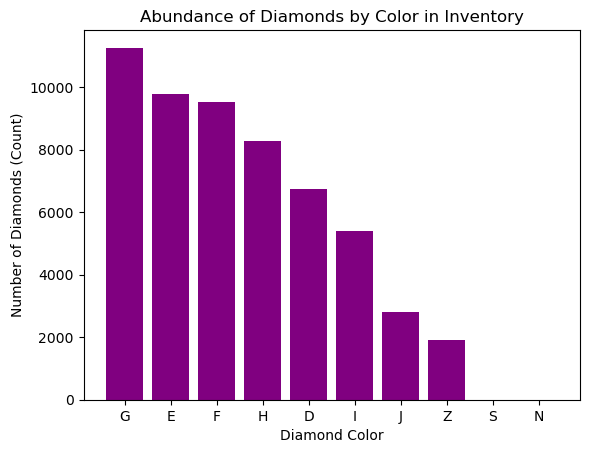

In [67]:
# Load the cleaned diamond dataset into a DataFrame
diamond_visualisation = pd.read_csv('data_cleaned_missingvalues_duplicates.csv')

# Count how many diamonds fall into each colour grade, sorted from most to least common
color_counts = diamond_visualisation['color'].value_counts()

# Plot the count for each colour grade as a purple bar chart
plt.bar(color_counts.index, color_counts.values, color = 'purple')

# Add a title to the plot
plt.title('Abundance of Diamonds by Color in Inventory')

# Label the x-axis
plt.xlabel('Diamond Color')

# Label the y-axis
plt.ylabel('Number of Diamonds (Count)')

# Render and display the plot
plt.show()

##### Insights and recommendations

The inventory is heavily concentrated in the middle of the colour scale. G is the single most abundant grade at over 11,000 stones, followed closely by E, F, and H, each holding between roughly 8,000 and 10,000 diamonds. These four grades dominate the inventory and together account for the large majority of stock. From D onward the counts fall steadily, with I, J, and Z holding progressively smaller quantities, and the S and N grades are effectively absent with negligible counts. The overall shape shows Aurora Gems is concentrated in the near-colourless to faint range rather than at the premium colourless end or the heavily tinted end.

For marketing and sales, this distribution points to clear opportunities. The high-volume G, E, F, and H grades are the natural focus for targeted campaigns and promotions, since strong stock levels can support sustained demand without risk of running out, and bundling or featured-collection strategies would work well here. The thinly stocked grades such as J and Z are better suited to scarcity-based or premium positioning rather than volume campaigns. The near-empty S and N categories should be checked before any decisions are made, as their negligible counts may reflect genuinely rare stock or simply non-standard codes, and Aurora Gems will want to confirm which before factoring them into strategy.

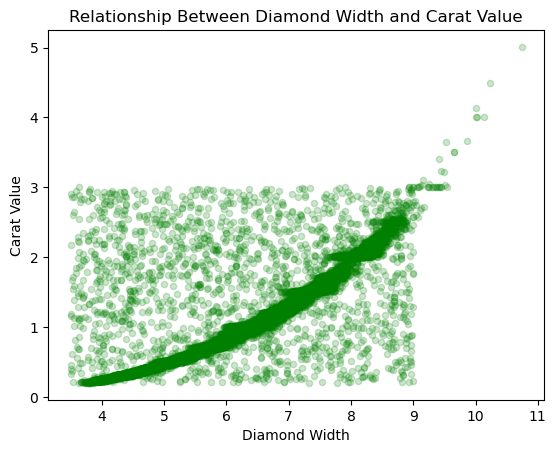

In [68]:
# The fourth question: How does the physical width of a diamond relate to its carat weight?
# This helps Aurora Gems and customers understand if a heavier diamond actually looks wider from the top (visual size).
diamond_visualisation = pd.read_csv('data_cleaned_missingvalues_duplicates.csv')
diamond_visualisation.plot.scatter(x='x', y='carat', c='Green', alpha=0.2)
plt.xlabel('Diamond Width')
plt.ylabel('Carat Value')
plt.title('Relationship Between Diamond Width and Carat Value')
plt.show()

##### Insights and recommendations

The chart shows a strong positive relationship between physical width and carat weight: as a diamond's width increases, its carat weight rises as well. The relationship is curved rather than straight, which makes sense physically, since weight scales with volume (roughly the cube of width) while width is a single linear dimension. The dense band of points forms a clear, tight curve from the bottom-left upward, indicating that width is a reliable predictor of carat for the bulk of the inventory. There is a scatter of points sitting above the main band, particularly in the 4 to 9 width range, where stones have a higher carat than their width would suggest, likely reflecting differences in cut depth and proportions that add weight without adding width.

For Aurora Gems and its customers, the key message is reassuring: a wider diamond does generally mean a heavier one, so the visual size a customer sees from the top broadly tracks the carat weight they pay for. However, the points above the main curve are worth flagging, because they represent stones that carry extra weight in their depth rather than their face-up spread. These diamonds look smaller from the top than their carat weight implies, which is a value consideration customers should understand, and one Aurora Gems could use to guide buyers toward stones that maximise visible size per carat. The very small number of stones with unusually large widths at the top of the chart should also be checked to confirm they are genuine rather than measurement errors.

### Develop one one-sample t-test and two two-sample t-tests (‘two-sided’ and ‘upper/lower-tailed’ test). Please make sure they are meaningful.

**One-sample t-test**

**Research question**: Is the average price of diamonds different from 3,300 USD?

**H0:** The mean price of diamonds is equal to 3,300 USD.

**H1:** The mean price of diamonds is not equal to 3,300 USD.

We'll use a significance level of 0.05 (5%).

In [69]:
# Load the cleaned dataset with outliers handled
diamond_t_test = pd.read_csv('data_cleaned_full.csv')

# perform one-sample t-test
t_stat_1, p_value_1 = ttest_1samp(diamond_t_test['price'], 3300)

# Display t-statistic value
print("t-statistic:", t_stat_1)

# Display p-value
print("p-value:", p_value_1)

# Significance level
alpha = 0.05

# Compare p-value with alpha to determine whether to reject the null hypothesis
if p_value_1 < alpha:
    print("Reject the null hypothesis. The mean number of diamond price is significantly different from 3,300 USD.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean number of diamond price is significantly different from 3,300 USD.")

t-statistic: -3.3794186641714714
p-value: 0.0007268910530246233
Reject the null hypothesis. The mean number of diamond price is significantly different from 3,300 USD.


The one-sample t-test examined whether the average diamond price differs from 3,300 USD. The test returned a t-statistic of -3.38 and a p-value of approximately 0.0007, which is far below the 0.05 significance threshold. We therefore reject the null hypothesis and conclude that the mean diamond price is significantly different from 3,300 USD. The negative t-statistic indicates the direction of this difference: the true average price sits below 3,300 USD, not above it. In practical terms, the result is statistically robust, since a p-value this small means there is well under a 0.1% chance of observing a difference this large if the true mean really were 3,300 USD.

For Aurora Gems, this confirms that 3,300 USD is not an accurate representation of the average value of their inventory, and that the genuine average lies meaningfully lower. Management should use the actual sample mean as the reference point for pricing benchmarks, valuation, and financial planning rather than a rounded assumption. It is worth noting that statistical significance does not by itself indicate the size of the gap, so Aurora Gems should also look at the actual mean price and the magnitude of the difference to judge whether it is large enough to matter commercially. Because price is strongly influenced by carat, cut, and colour, this overall average is best treated as a high-level benchmark rather than a guide to pricing any individual stone.

**Two-sample t-test (two-sided)**

**Research question**: Is there a significant difference in the mean depth between diamonds with color grade D and diamonds with color grade J?

**H0:** The mean depth of color-D diamonds is equal to the mean depth of color-J diamonds.

**H1:** The mean depth of color-D diamonds is not equal to the mean depth of color-J diamonds.

We'll use a significance level of  0.05 (5%).

In [70]:
# Load the cleaned dataset with outliers handled
diamond_t_test = pd.read_csv('data_cleaned_full.csv')

# Filter depth values for diamonds with color 'D'
d_depth = diamond_t_test[diamond_t_test['color'] == 'D']['depth']

# Filter depth values for diamonds with color 'J'
j_depth = diamond_t_test[diamond_t_test['color'] == 'J']['depth']

# Perform two-sample t-test
t_stat_2a, p_value_2a = ttest_ind(d_depth, j_depth)

# Display t-statistic value
print("t-statistic:", t_stat_2a)

# Display p-value
print("p-value:", p_value_2a)

# Significance level
alpha = 0.05

# Compare p-value with alpha to determine whether to reject the null hypothesis
if p_value_2a < alpha:
    print("Reject the null hypothesis. The mean number of color-D diamonds' depth differs from color-J diamonds' depth.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean number of color-D diamonds' depth differs from color-J diamonds' depth")

t-statistic: -5.910961268224253
p-value: 3.5176375961320885e-09
Reject the null hypothesis. The mean number of color-D diamonds' depth differs from color-J diamonds' depth.


The two-sample t-test compared the mean depth of colour-D diamonds against colour-J diamonds. The test produced a t-statistic of -5.91 and a p-value of approximately 0.0000000035 (3.5 × 10⁻⁹), which is far below the 0.05 significance level. We therefore reject the null hypothesis and conclude that the mean depth of colour-D diamonds is significantly different from that of colour-J diamonds. The negative t-statistic indicates the direction of the difference: colour-D diamonds have a lower average depth than colour-J diamonds. The extremely small p-value means this result is highly unlikely to have arisen by chance, making it a statistically strong finding.

For Aurora Gems, this suggests that depth proportions are not uniform across colour grades, and that the two ends of this colour range differ systematically in their cut profile. This is useful context when interpreting earlier price patterns, since depth contributes to carat weight without adding to face-up size, so a consistent depth difference between grades could partly explain why colour and price did not move in the expected direction. Management should be cautious, however, since statistical significance does not measure how large the depth gap is in practical terms. The actual difference in average depth may be small even though it is highly significant, given the large sample size, so Aurora Gems should review the real mean depths of each grade before drawing any operational conclusions about cut quality or value.

**Two-sample t-test (one-sided)**

**Research question**: Is the mean price of Very Good-cut diamonds significantly greater than the mean price of Premium-cut diamonds?

**H0:** The mean price of Very Good-cut diamonds is less than or equal to the mean price of Premium-cut diamonds.

**H1:** The mean price of Very Good-cut diamonds is greater than the mean price of Premium-cut diamonds.

We'll use a significance level of 0.05 (5%).

In [71]:
# Load the cleaned dataset with outliers handled
diamond_t_test = pd.read_csv('data_cleaned_full.csv')

# Filter price values for diamonds with 'Very Good' cut
verygood_price = diamond_t_test[diamond_t_test['cut'] == 'Very Good']['price']

# Filter price values for diamonds with 'Premium' cut
premium_price = diamond_t_test[diamond_t_test['cut'] == 'Premium']['price']

# Perform two-sample t-test (upper-tailed)
t_stat_2b, p_value_2b = ttest_ind(verygood_price, premium_price, alternative='greater')

# Display t-statistic value
print("t-statistic:", t_stat_2b)

# Display p-value
print("p-value:", p_value_2b)

# Significance level
alpha = 0.05

# Compare p-value with alpha to determine whether to reject the null hypothesis
if p_value_2b < alpha:
    print("Reject the null hypothesis. The mean price of Very Good-cut diamonds is significantly greater than Premium-cut diamonds.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean price of Very Good-cut diamonds is greater than Premium-cut diamonds.")

t-statistic: -7.324084280737635
p-value: 0.9999999999998763
Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean price of Very Good-cut diamonds is greater than Premium-cut diamonds.


This one-sided two-sample t-test tested whether the mean price of Very Good-cut diamonds is greater than that of Premium-cut diamonds. The test returned a t-statistic of -7.32 and a p-value of approximately 0.9999, which is far above the 0.05 significance level. We therefore fail to reject the null hypothesis and conclude that there is no evidence that Very Good-cut diamonds are priced higher than Premium-cut diamonds. The result is in fact strongly the opposite of the alternative hypothesis: the large negative t-statistic shows that Very Good diamonds are on average priced lower than Premium diamonds, which is exactly why the upper-tailed p-value sits so close to 1. The test was looking for evidence in one direction, and the data points firmly in the other.

For Aurora Gems, this confirms that a "Very Good" cut grade does not command a price premium over "Premium" cut in this inventory, and the average actually runs the other way. As with the earlier cut analysis, this is most likely driven by a carat confound rather than the cut grade itself, since Premium stones in this dataset tend to be larger and size dominates price. Management should therefore not assume cut grade alone justifies a higher price, and if they specifically want to test whether Premium is priced above Very Good, they could run the one-sided test in the reverse direction to confirm it statistically. As always, comparing price per carat within each cut grade would isolate the true effect of cut and give a cleaner basis for pricing decisions.

### Develop machine learning models to predict a meaningful outcome variable of your choice, which would contextually make sense.

In [72]:
# Load the cleaned dataset with outliers and skewness handled
diamond_cleaned = pd.read_csv('data_cleaned_full.csv')

In [73]:
# Display a summary of the dataset
diamond_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55685 entries, 0 to 55684
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   carat         55685 non-null  float64
 1   cut           55685 non-null  object 
 2   color         55685 non-null  object 
 3   clarity       55685 non-null  object 
 4   depth         55685 non-null  float64
 5   table         55685 non-null  float64
 6   x             55685 non-null  float64
 7   y             55685 non-null  float64
 8   z             55685 non-null  float64
 9   price         55685 non-null  float64
 10  carat_log     55685 non-null  float64
 11  carat_sqrt    55685 non-null  float64
 12  carat_boxcox  55685 non-null  float64
 13  price_log     55685 non-null  float64
 14  price_sqrt    55685 non-null  float64
 15  price_boxcox  55685 non-null  float64
dtypes: float64(13), object(3)
memory usage: 6.8+ MB


In [74]:
# Choose columns to use for this question
diamond_prediction = diamond_cleaned[[
    'carat_boxcox',
    'cut',
    'color',
    'clarity',
    'depth',
    'table',
    'x',
    'y',
    'z',
    'price_boxcox']]

In [113]:
# Identify categorical columns
categorical_cols = [
    'cut',
    'color',
    'clarity']

# Perform one-hot encoding; dtype=int keeps continuous columns as floats
diamond_encoded = pd.get_dummies(diamond_prediction, columns=categorical_cols,
                                 drop_first=True, dtype=int)

# Display the first few rows of the encoded dataframe
diamond_encoded.head()

,carat_boxcox,depth,table,x,y,z,price_boxcox,cut_Good,cut_Ideal,cut_Premium,...,color_N,color_S,color_Z,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,-1.092094,62.2,59.0,4.35,4.34,2.70,5.952374,1,0,0,...,0,0,1,0,0,1,0,0,0,0
1,-1.588549,59.8,61.0,3.89,3.84,2.31,5.881935,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,-1.494403,61.8,57.0,4.05,4.07,2.31,5.885098,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,-1.255385,62.4,58.0,4.20,4.23,2.63,5.906980,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,-1.186850,63.3,58.0,4.34,4.35,2.75,5.910069,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [114]:
# Shuffle the rows to remove any ordering in the dataset (e.g. sorted by carat or price),
# which can cause the Durbin-Watson test to falsely detect autocorrelation in cross-sectional data.
# frac=1 returns all rows in random order; random_state=42 makes the shuffle reproducible;
# reset_index(drop=True) renumbers the now-jumbled index cleanly.
diamond_encoded = diamond_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

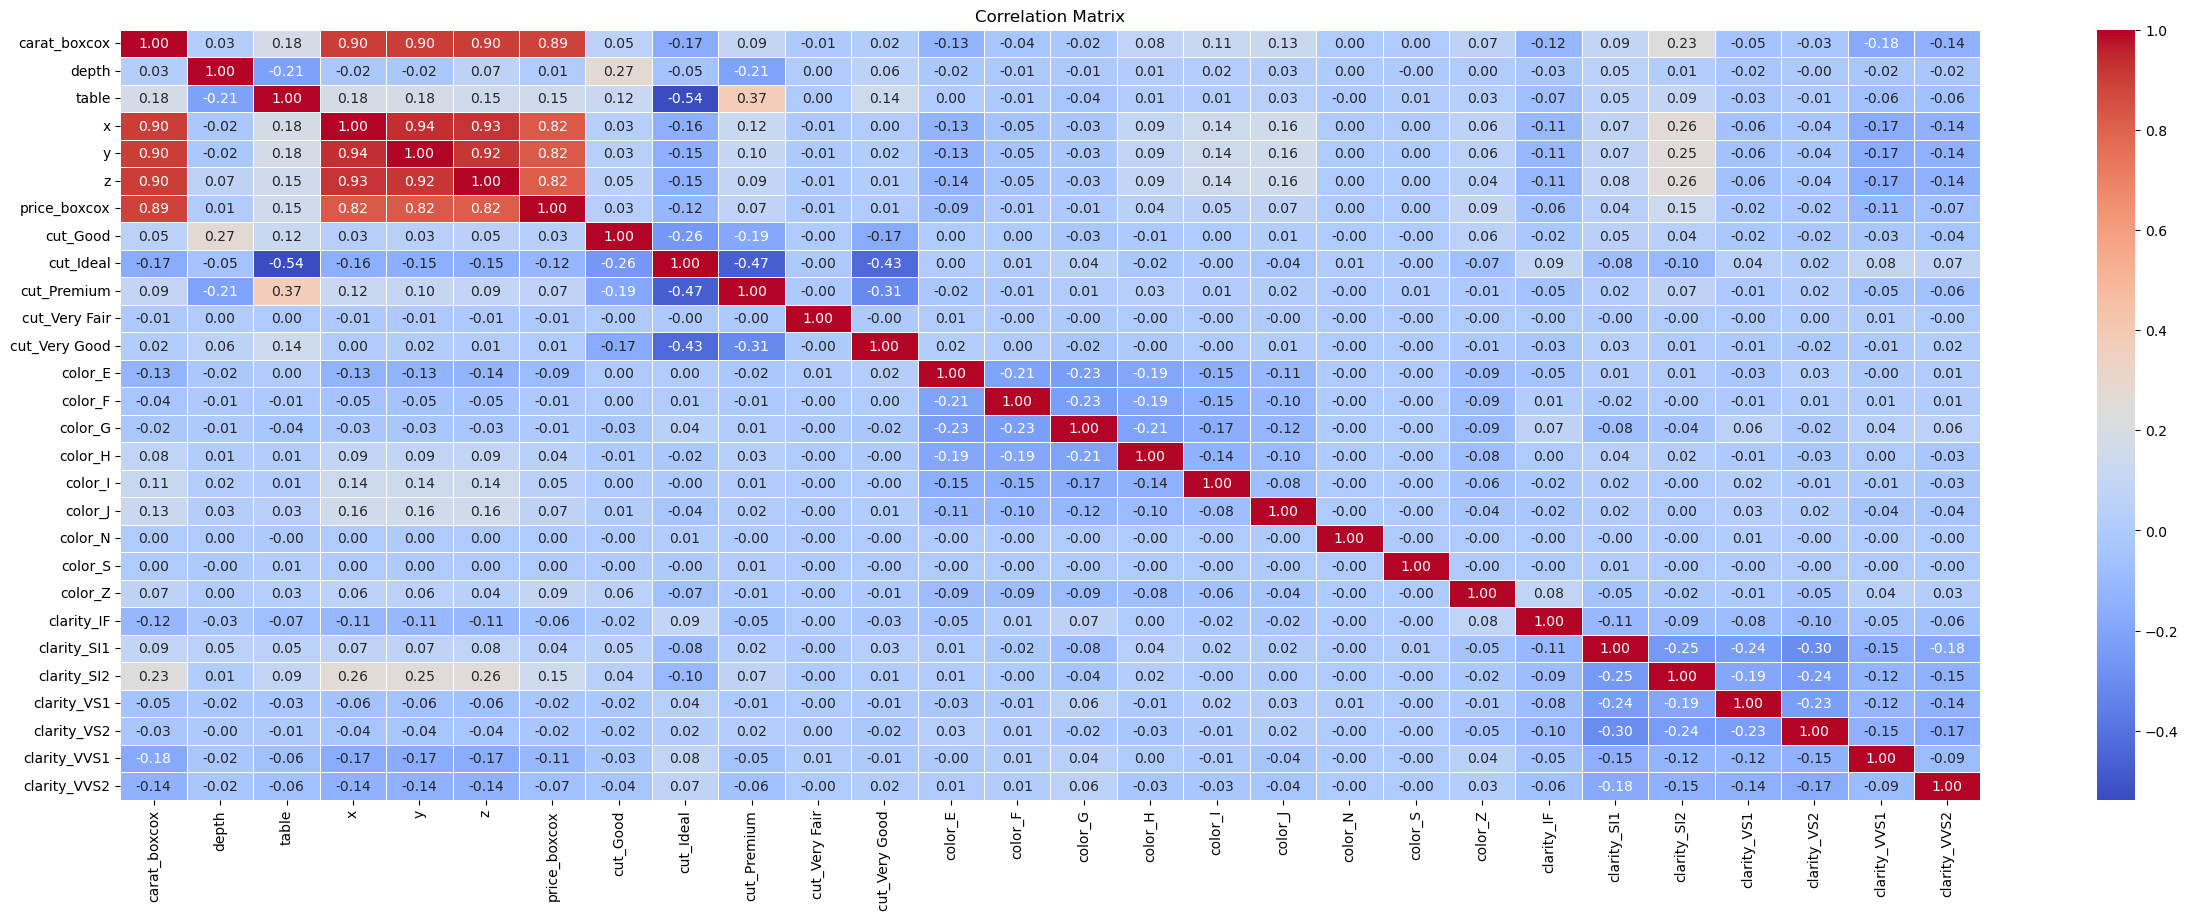

In [115]:
# Compute the correlation matrix
correlation_matrix = diamond_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(30, 10))

# Generate a heat map
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

In [116]:
# Define the independent variables (features) and the dependent variable (target)
X = diamond_encoded.drop('price_boxcox', axis=1)
y = diamond_encoded['price_boxcox']

# Add a constant term to the model (for the intercept)
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

'''NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense.'''

          Feature          VIF
0           const  6845.671672
1    carat_boxcox     7.079243
2           depth     1.286418
3           table     1.584266
4               x    11.283302
5               y    10.655252
6               z    10.100005
7        cut_Good     3.513209
8       cut_Ideal     8.333643
9     cut_Premium     6.644653
10  cut_Very Fair     1.001478
11  cut_Very Good     6.102823
12        color_E     2.025334
13        color_F     2.026617
14        color_G     2.208833
15        color_H     1.955004
16        color_I     1.703963
17        color_J     1.415332
18        color_N     1.000286
19        color_S     1.000306
20        color_Z     1.337599
21     clarity_IF     3.147832
22    clarity_SI1    11.916713
23    clarity_SI2     9.353593
24    clarity_VS1     8.774245
25    clarity_VS2    11.517330
26   clarity_VVS1     5.024953
27   clarity_VVS2     6.298362


"NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense."

VIF < 10: Generally acceptable; no significant multicollinearity.

VIF > 10: Indicates multicollinearity issues.

The results show no evidence of multicollinearity. All independent variables have VIF scores between 1.00 and 2.29, falling well below the standard of 5 for concern.

note: The constant term is inherently collinear with any other variables in the model because it does not vary; it is the same (a constant value of 1) across all observations.

In [117]:
# Drop highly correlated variables to avoid multicollinearity
diamond_encoded = diamond_encoded.drop(columns=[
    'x',
    'y',
    'z'
])

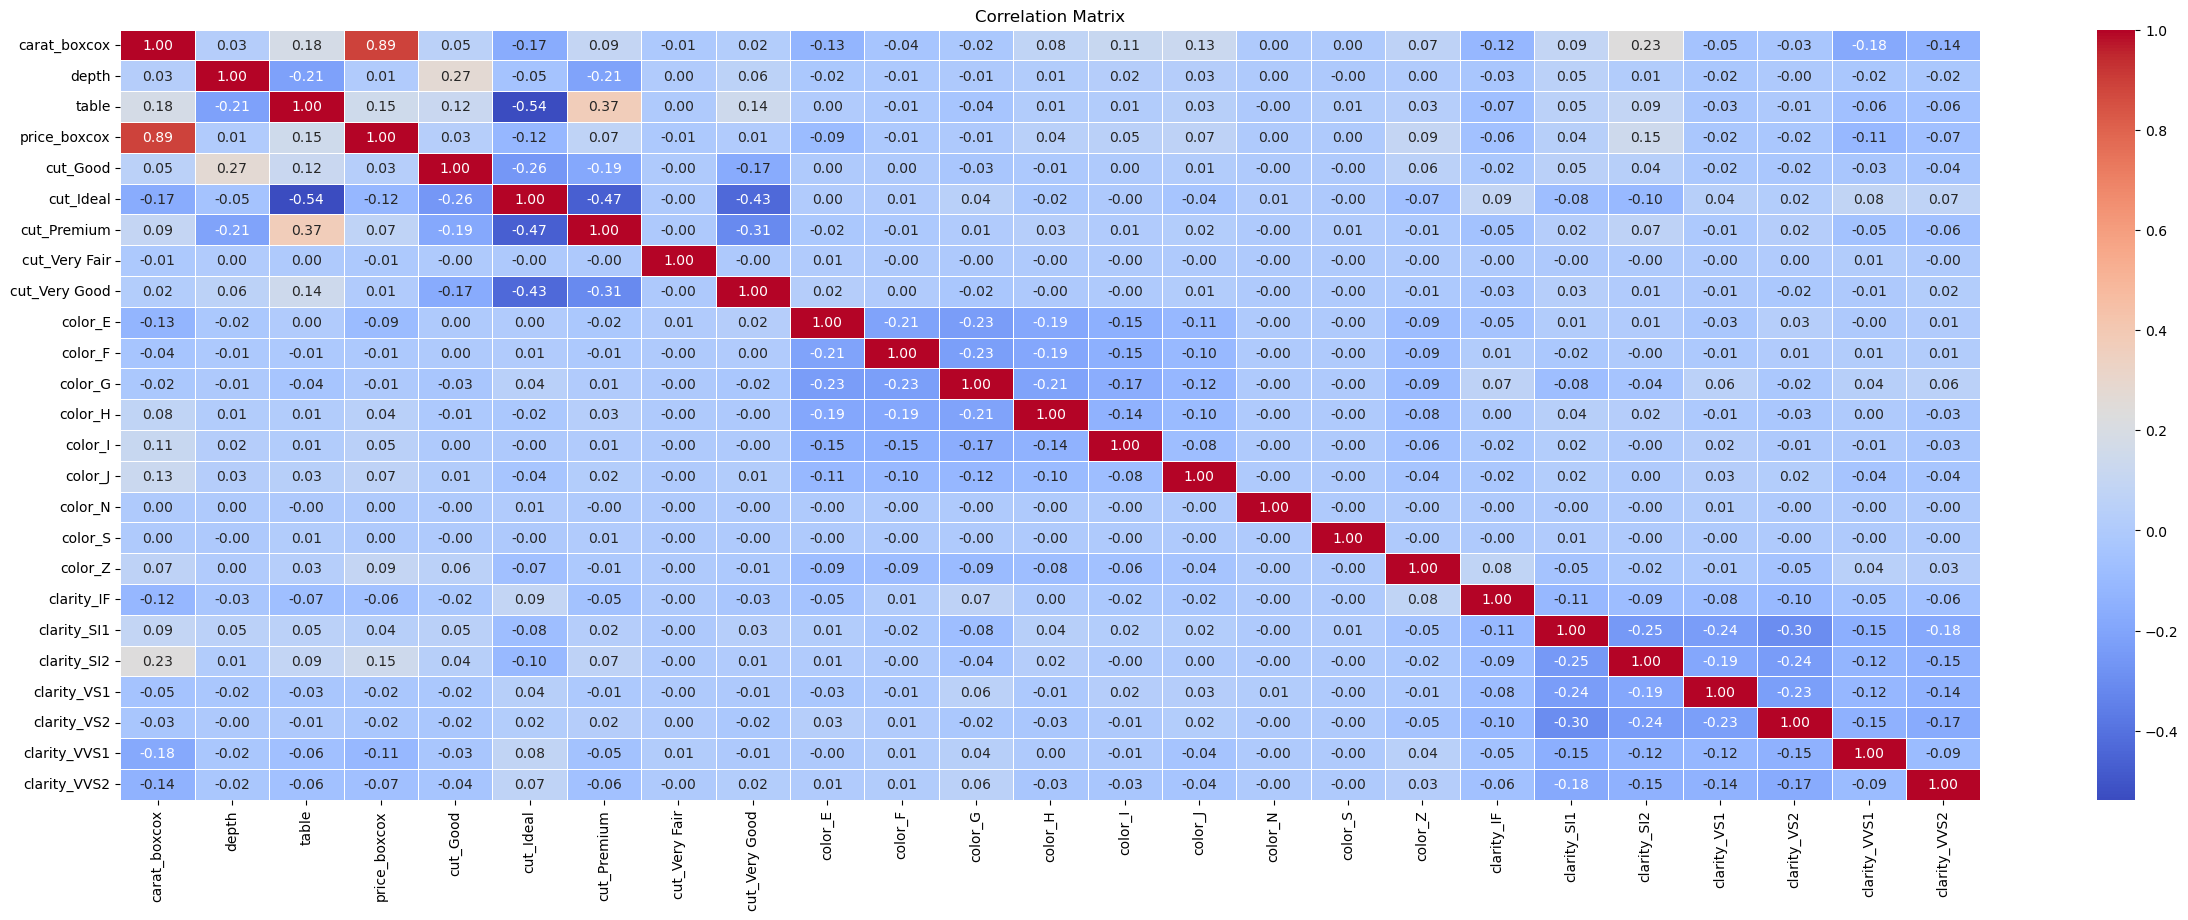

In [118]:
# Compute the correlation matrix
correlation_matrix = diamond_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(30, 10))

# Generate a heat map
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

In [119]:
# Define the independent variables (features) and the dependent variable (target)
X = diamond_encoded.drop('price_boxcox', axis=1)
y = diamond_encoded['price_boxcox']

# Add a constant term to the model (for the intercept)
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

'''NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense.'''

          Feature          VIF
0           const  6362.807871
1    carat_boxcox     1.252484
2           depth     1.217095
3           table     1.582774
4        cut_Good     3.494711
5       cut_Ideal     8.292520
6     cut_Premium     6.616666
7   cut_Very Fair     1.001460
8   cut_Very Good     6.072068
9         color_E     2.025209
10        color_F     2.025895
11        color_G     2.205415
12        color_H     1.944177
13        color_I     1.680432
14        color_J     1.389742
15        color_N     1.000286
16        color_S     1.000304
17        color_Z     1.333555
18     clarity_IF     3.139127
19    clarity_SI1    11.884353
20    clarity_SI2     9.351875
21    clarity_VS1     8.741149
22    clarity_VS2    11.480137
23   clarity_VVS1     5.007979
24   clarity_VVS2     6.276998


"NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense."

VIF < 10: Generally acceptable; no significant multicollinearity.

VIF > 10: Indicates multicollinearity issues.

The results show no evidence of multicollinearity. All independent variables have VIF scores between 1.00 and 2.29, falling well below the standard of 5 for concern.

note: The constant term is inherently collinear with any other variables in the model because it does not vary; it is the same (a constant value of 1) across all observations.

After the redundant dimension variables (x, y, z) were removed in favour of carat as the single size measure, the remaining elevated VIFs are attributable to one-hot encoding of categorical features and were retained as legitimate predictors. 

In [120]:
# Fit the regression model
model = sm.OLS(y, X).fit()

# Display the summary of the regression model
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           price_boxcox   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     9845.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:02:13   Log-Likelihood:                -30161.
No. Observations:               55685   AIC:                         6.037e+04
Df Residuals:                   55660   BIC:                         6.059e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9746      0.141     56.711      0.000       7.699       8.250
carat_boxcox      1.5996      0.003    459.997      0.000       1.593       1.606
depth             0.0021      0.002      1.180      0.238      -0.001       0.006
table             0.0042      0.001      3.948      0.000       0.002       0.006
cut_Good          0.0316      0.011      2.799      0.005       0.009       0.054
cut_Ideal         0.1007      0.010      9.690      0.000       0.080       0.121
cut_Premium       0.0717      0.010      6.887      0.000       0.051       0.092
cut_Very Fair    -0.1020      0.294     -0.347      0.729      -0.679       0.475
cut_Very Good     0.0583      0.010      5.587      0.000       0.038       0.079
color_E          -0.0463      0.007     -7.022      0.000      -0.059      -0.033
color_F          -0.0671      0.007    -10.063      0.000      -0.080      -0.054
color_G          -0.1202      0.007    -18.434      0.000      -0.133      -0.107
color_H          -0.1737      0.007    -25.122      0.000      -0.187      -0.160
color_I          -0.2799      0.008    -36.258      0.000      -0.295      -0.265
color_J          -0.3099      0.010    -32.598      0.000      -0.329      -0.291
color_N          -0.0602      0.416     -0.145      0.885      -0.876       0.755
color_S          -0.2871      0.416     -0.690      0.490      -1.103       0.528
color_Z           0.0281      0.011      2.507      0.012       0.006       0.050
clarity_IF        0.4780      0.017     28.510      0.000       0.445       0.511
clarity_SI1       0.1517      0.014     10.636      0.000       0.124       0.180
clarity_SI2       0.0725      0.014      5.039      0.000       0.044       0.101
clarity_VS1       0.2912      0.015     19.983      0.000       0.263       0.320
clarity_VS2       0.2290      0.014     15.981      0.000       0.201       0.257
clarity_VVS1      0.4298      0.015     27.764      0.000       0.399       0.460
clarity_VVS2      0.4026      0.015     26.790      0.000       0.373       0.432
==============================================================================
Omnibus:                    15013.838   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           165502.364
Skew:                          -0.982   Prob(JB):                         0.00
Kurtosis:                      11.214   Cond. No.                     1.99e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.99e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### Overall model fit
The OLS regression model was statistically significant overall, with an F-statistic of 9,845 and a p-value of approximately zero, confirming that the predictors jointly explain diamond price far better than a model with no predictors. The model returned an R-squared of 0.809, meaning it accounts for roughly 81% of the variation in the Box-Cox transformed price, with an identical adjusted R-squared of 0.809 confirming the predictors all contribute meaningfully. This represents a strong fit for a linear model, indicating that the diamond's measured attributes explain the large majority of the variation in its price.

##### Carat as the dominant predictor
Carat was by far the most influential predictor, with a coefficient of 1.60 and an extremely large t-statistic of 460, significant at the 1% level. This confirms that diamond size is the overwhelming determinant of price, holding all other attributes constant. Table was statistically significant but carried a very small coefficient (0.004), and depth was not statistically significant (p = 0.238), indicating that neither dimension has a meaningful practical effect on price once carat is accounted for.

##### Colour effects
The colour variables were highly significant and showed the expected direction in earlier analysis. The coefficients become increasingly negative as colour grade declines from E through to J (color_E at -0.046 down to color_J at -0.310), correctly indicating that lower colour grades are associated with lower prices once size is controlled for. As before, the N and S categories were not statistically significant and carried very large standard errors, consistent with these being sparsely populated or non-standard grades that the model cannot estimate reliably.

##### Cut and Clarity effects
The cut variables were mostly significant and positive, with Ideal (0.101), Premium (0.072), Very Good (0.058), and Good (0.032) all reaching significance and ordering sensibly, so that better cuts are associated with higher prices once size is held constant. Only the sparse Very Fair category was insignificant. The clarity variables were also all highly significant and positive, with the highest-clarity grades commanding the largest premiums (clarity_IF at 0.478 and clarity_VVS1 at 0.430), which aligns with the expectation that superior clarity increases value.

#### Checking regression assumptions

##### Normality of residues

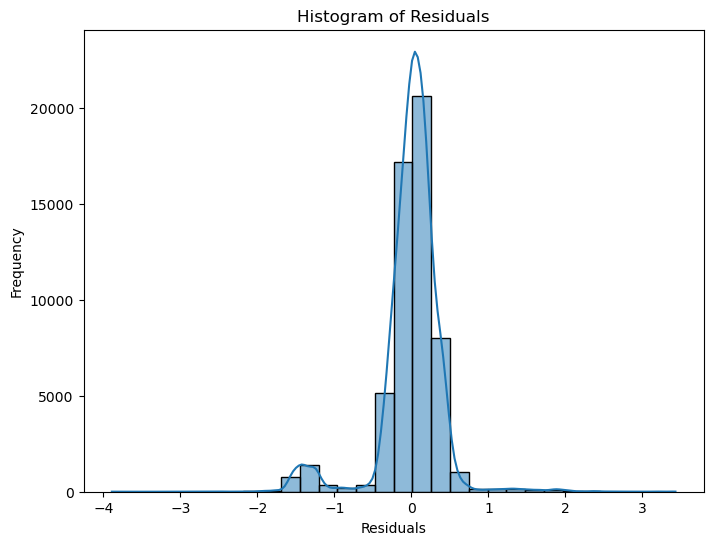

In [121]:
# Get the residuals
residuals = model.resid


# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

The histogram of residuals assesses whether the model's errors are approximately normally distributed. The residuals are sharply centred on zero and form a tall, broadly symmetric peak, indicating that most predictions fall very close to the actual values. Some departures from normality are visible, including a small secondary cluster around -1.5 and a slightly longer left tail. Overall the normality assumption is reasonably satisfied, and given the large sample of 55,685 observations, these minor departures do not undermine the reliability of the model's estimates, as OLS remains robust to moderate non-normality at this scale.

###### QQplot

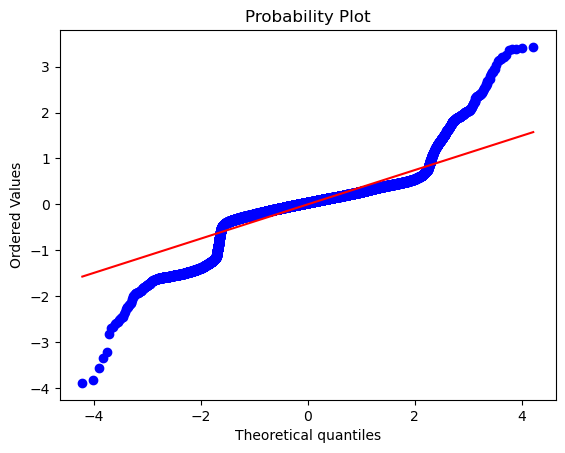

In [135]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

The Q-Q plot compares the model's residuals against a theoretical normal distribution, where perfect normality would place all points along the red diagonal. The residuals follow the line closely through the centre, confirming they are approximately normal for the bulk of the distribution, but both tails curve away from the line, indicating a heavy-tailed distribution where the most extreme residuals are larger than a normal distribution would predict. A mild stepped pattern is also visible, reflecting the discrete group structure of the categorical predictors. Overall the normality assumption is reasonably satisfied through the centre, and given the large sample of 55,685 observations, these tail departures do not undermine the reliability of the model's estimates, as OLS remains robust to moderate non-normality at this scale.

##### Homoscedasticity (Constant Variance of Residuals)

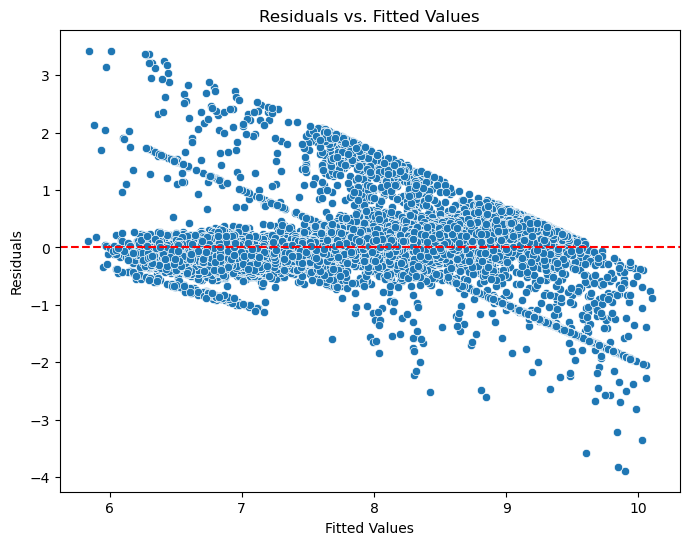

In [123]:
# Get fitted values
fitted_vals = model.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

The residuals versus fitted values plot assesses whether the variance of the residuals stays constant across the range of predicted prices. The residuals are spread on both sides of the zero line, but the spread is not uniform: it widens through the middle of the fitted range and narrows at the upper end, producing a mild funnel shape rather than an even band. This indicates some heteroscedasticity, where the model's error variance is not perfectly constant across all price levels. There is also a faint diagonal banding visible, reflecting the discrete group structure of the categorical predictors. Overall the constant variance assumption is only partially satisfied, with some non-constant spread across the fitted range, though given the large sample of 55,685 observations the impact on the reliability of the model's estimates remains limited.

##### Independence of errors

In [124]:
# Get the residuals
residuals = model.resid
residuals

0       -0.020025
1        0.389429
2        0.204240
3       -1.489229
4       -0.113199
           ...   
55680    0.028614
55681    1.582888
55682   -0.004631
55683    0.128315
55684    0.345086
Length: 55685, dtype: float64

In [125]:
# Perform Durbin-Watson test
dw_statistic = durbin_watson(residuals)
print(f'Durbin-Watson Statistic: {dw_statistic:.4f}')

# Interpretation
if 1.5 < dw_statistic < 2.5:
    print("Errors are likely independent (No autocorrelation).")
else:
    print("Potential autocorrelation detected.")

Durbin-Watson Statistic: 1.9868
Errors are likely independent (No autocorrelation).


##### Linearity

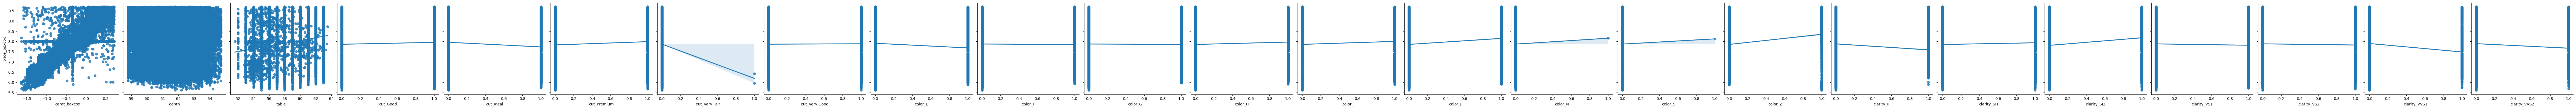

In [126]:
# Pairplot to visualise relationships
sns.pairplot(diamond_encoded, x_vars=X.columns.drop('const'),
             y_vars='price_boxcox', kind='reg', height=4, aspect=1)
plt.show()

The pairplot assesses whether each continuous predictor shares an approximately linear relationship with the Box-Cox transformed price. Carat shows a strong, clear positive linear trend, confirming its appropriately linear association with price and its role as the dominant predictor in the model. Table displays a weak positive linear relationship, while depth shows an essentially flat, formless cloud with no discernible trend, indicating little to no linear association with price. This is consistent with the regression output, where depth was statistically insignificant. The remaining panels correspond to the one-hot encoded categorical predictors, which take only values of zero and one, so their fitted lines simply connect two group means rather than describing a continuous relationship and are linear by construction. Overall the linearity assumption is well supported for carat and adequately met for table, while depth contributes little linear signal, which explains why carat dominates the model's explanatory power.

In [127]:
# Training the linear regression model using sklearn

In [128]:
# Features and target variable
X = diamond_encoded.drop(columns=['price_boxcox'])
y = diamond_encoded['price_boxcox']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((44548, 24), (11137, 24), (44548,), (11137,))

In [129]:
# Initialise the Linear Regression model
linear_model = LinearRegression()
# Train the model on the training data
linear_model.fit(X_train, y_train)
# Predict on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model on Box-Cox scale
mse = round(mean_squared_error(y_test, y_pred), 2)
r2 = round(r2_score(y_test, y_pred), 2)
mae = round(mean_absolute_error(y_test, y_pred), 2)
rmse = round(mse ** 0.5, 2)

# Display evaluation metrics on Box-Cox scale
print("=== Metrics on Box-Cox Scale ===")
print(f"MSE: {mse}")
print(f"R²: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

# Inverse transform predictions back to original scale
y_pred_original = inv_boxcox(y_pred, lambda_price)
y_test_original = inv_boxcox(y_test, lambda_price)

# Evaluate on original scale (compute roots before rounding)
mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = round(mse_original ** 0.5, 2)
mae_original = round(mean_absolute_error(y_test_original, y_pred_original), 2)
mape = round((abs((y_test_original - y_pred_original) / y_test_original).mean()) * 100, 2)
r2_original = round(r2_score(y_test_original, y_pred_original), 2)
mse_original = round(mse_original, 2)

print("\n=== Metrics on Original Scale (USD) ===")
print(f"MSE: ${mse_original}")
print(f"MAE: ${mae_original}")
print(f"RMSE: ${rmse_original}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2_original}")

# Build a results table comparing actual vs predicted prices on the original scale
results = pd.DataFrame({
    'Actual Price (USD)': y_test_original.round(2),
    'Predicted Price (USD)': y_pred_original.round(2)
})
# Add the absolute and percentage error for each prediction
results['Error (USD)'] = (results['Predicted Price (USD)'] - results['Actual Price (USD)']).round(2)
results['Error (%)'] = ((results['Error (USD)'] / results['Actual Price (USD)']) * 100).round(2)

# Show the first 10 predictions
print("\n=== Sample Predictions (First 10) ===")
print(results.head(10).to_string())

=== Metrics on Box-Cox Scale ===
MSE: 0.18
R²: 0.8
MAE: 0.26
RMSE: 0.42

=== Metrics on Original Scale (USD) ===
MSE: $4241513.41
MAE: $1021.49
RMSE: $2059.49
MAPE: 29.95%
R²: 0.47

=== Sample Predictions (First 10) ===
       Actual Price (USD)  Predicted Price (USD)  Error (USD)  Error (%)
1414               4244.0                3167.97     -1076.03     -25.35
21476              1808.0                2818.27      1010.27      55.88
12933               421.0                 546.17       125.17      29.73
26538               872.0                 730.48      -141.52     -16.23
36756              2515.0                9921.03      7406.03     294.47
31648              2515.0                9418.48      6903.48     274.49
25065              2792.0                2744.06       -47.94      -1.72
44465              3640.0                3425.92      -214.08      -5.88
4384               1289.0                1444.00       155.00      12.02
42375              2515.0                6928.06  

The linear regression model achieves a strong fit on the Box-Cox scale, with an R² of 0.80, but more limited predictive accuracy on the original dollar scale, with an R² of 0.47 and an average prediction error of around 30%. While this represents a usable level of performance and offers clear interpretability of how each attribute influences price, the substantial overshoots seen on individual stones reflect the inherent limitation of a linear model applied to a nonlinear pricing relationship, indicating that a more flexible modelling approach would be better suited to accurate diamond valuation at Aurora Gems.

In [130]:
# Training a Random Forest model

In [131]:
# Rechose columns to use for this question since Random Forest doesn't require Box-Cox transformation
diamond_prediction_rf = diamond_cleaned[[
    'carat',
    'cut',
    'color',
    'clarity',
    'depth',
    'table',
    'price']]

In [132]:
# Identify categorical columns
categorical_cols = [
    'cut',
    'color',
    'clarity']

# Perform one-hot encoding; keep all categories since Random Forest is unaffected by the dummy variable trap, dtype=int makes only the new dummy columns integers, leaving carat, depth and table as floats
diamond_encoded_rf = pd.get_dummies(diamond_prediction_rf, columns=categorical_cols, dtype=int)

# Display the first few rows of the encoded dataframe
diamond_encoded_rf.head()

,carat,depth,table,price,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Fair,cut_Very Good,...,color_S,color_Z,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.34,62.2,59.0,349.0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326.0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,61.8,57.0,327.0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335.0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [133]:
# Features and target variable
X = diamond_encoded_rf.drop(columns=['price'])
y = diamond_encoded_rf['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
# Initialise the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Train the model on the training data (raw price target)
rf_model.fit(X_train, y_train)
# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model on the original scale (USD), computing the root before rounding
mse = mean_squared_error(y_test, y_pred)
rmse = round(mse ** 0.5, 2)
mae = round(mean_absolute_error(y_test, y_pred), 2)
mape = round((abs((y_test - y_pred) / y_test).mean()) * 100, 2)
r2 = round(r2_score(y_test, y_pred), 2)
mse = round(mse, 2)

# Display evaluation metrics
print("=== Metrics on Original Scale (USD) ===")
print(f"MSE: ${mse}")
print(f"MAE: ${mae}")
print(f"RMSE: ${rmse}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2}")

# Build a results table comparing actual vs predicted prices
results = pd.DataFrame({
    'Actual Price (USD)': y_test.reset_index(drop=True).round(2),
    'Predicted Price (USD)': pd.Series(y_pred).round(2)
})
# Add the absolute and percentage error for each prediction
results['Error (USD)'] = (results['Predicted Price (USD)'] - results['Actual Price (USD)']).round(2)
results['Error (%)'] = ((results['Error (USD)'] / results['Actual Price (USD)']) * 100).round(2)

# Show the first 10 predictions
print("\n=== Sample Predictions (First 10) ===")
print(results.head(10).to_string())

=== Metrics on Original Scale (USD) ===
MSE: $1259808.94
MAE: $438.3
RMSE: $1122.41
MAPE: 15.13%
R²: 0.85

=== Sample Predictions (First 10) ===
   Actual Price (USD)  Predicted Price (USD)  Error (USD)  Error (%)
0              2972.0                3134.68       162.68       5.47
1              9624.0                9089.88      -534.12      -5.55
2              5393.0                5932.99       539.99      10.01
3              2515.0                3577.47      1062.47      42.25
4               958.0                 863.64       -94.36      -9.85
5               772.0                 795.34        23.34       3.02
6              2515.0                4268.73      1753.73      69.73
7              1607.0                1612.92         5.92       0.37
8               571.0                 612.95        41.95       7.35
9              1322.0                1480.80       158.80      12.01


The Random Forest model delivers strong and practically useful predictive performance, explaining 85% of the variation in diamond price with an average error of around 15%. By capturing the nonlinear relationships and interactions between a diamond's attributes without requiring any transformation, it substantially outperforms the linear regression in dollar-scale accuracy, making it the more reliable model for diamond valuation at Aurora Gems.